# **Step 6 : Training and Evaluating Models**

In [3]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization, Input, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K
from collections import Counter
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product
import numpy as np
import pandas as pd
import os
import pickle
import joblib
from datetime import datetime
import json

df= pd.read_csv("enhanced_dataset.csv")
df.head()

,date,year,month,day,dayofweek,is_weekend,dayofyear,month_sin,month_cos,dayofyear_sin,...,relative_humidity_2m_max__lag_7,relative_humidity_2m_max__rolling_mean_7d,relative_humidity_2m_max__rolling_std_7d,relative_humidity_2m_max__7day_trend,cloud_rain_interaction,temp_humidity_interaction,precip_cloud_interaction,cloud_volatility_7d,rain_volatility_7d,temp_seasonal_anomaly
0,2000-01-01,2000,1,1,5,True,1,0.5,0.866025,0.017202,...,NaN,86.0,NaN,NaN,169.1,384.0,712.0,NaN,NaN,-4.850000
1,2000-01-02,2000,1,2,6,True,2,0.5,0.866025,0.034398,...,NaN,85.5,0.707107,NaN,21.6,313.6,72.0,12.020815,1.131371,-3.669231
2,2000-01-03,2000,1,3,0,False,3,0.5,0.866025,0.051584,...,NaN,84.0,2.645751,NaN,117.5,315.0,282.0,21.126603,1.137248,-4.311538
3,2000-01-04,2000,1,4,1,False,4,0.5,0.866025,0.068755,...,NaN,83.0,2.943920,NaN,0.0,254.4,0.0,22.750458,1.214839,-3.134615
4,2000-01-05,2000,1,5,2,False,5,0.5,0.866025,0.085906,...,NaN,84.4,4.037326,NaN,0.0,527.8,0.0,20.777392,1.176010,-3.203846


**Option 1 : Sliding window + sequence length = 7 ----> 3 days forecast + combaining Partly cloudy and mainly clear into Partly Clear**

In [ ]:
class ImprovedSlidingWindowModel:
    def __init__(self, df, sequence_length=7, forecast_horizon=3):
        """
        Improved sliding window + rebalancing model with better class handling
        """
        self.df = df.copy()
        self.forecast_horizon = forecast_horizon
        self.sequence_length = sequence_length
        self.scaler_X = None
        self.label_encoder = None
        self.model = None
        self.class_weights = None
        
        # Improved thresholds for better balance
        self.minority_threshold = 0.08   # Very rare classes
        self.balanced_threshold = 0.20   # Medium frequency classes
        # Above 20% = majority classes
        
    def preprocess_data(self, target_col='weather_condition'):
        """Enhanced preprocessing with three-tier class categorization"""
        print("🧹 Enhanced preprocessing...")
        df = self.df.copy()
        
        # Handle missing values
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col != target_col:
                df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
                df[col] = df[col].interpolate(method='linear')
                df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with missing target
        df = df.dropna(subset=[target_col])
        # 🔄 Merge specific weather classes
        df[target_col] = df[target_col].replace({
            'Mainly Clear 🌤': 'Partly Clear 🌤/⛅',
            'Partly Cloudy ⛅': 'Partly Clear 🌤/⛅'
        })
        
        # Three-tier class analysis
        class_counts = df[target_col].value_counts()
        total_samples = len(df)
        print(f"Original class distribution:\n{class_counts}")
        print(f"Class percentages:\n{(class_counts/total_samples*100).round(2)}")
        
        # Categorize classes into three tiers
        self.minority_classes = []    # < 8%
        self.balanced_classes = []    # 8% - 20%  
        self.majority_classes = []    # > 20%
        
        for class_name, count in class_counts.items():
            percentage = count / total_samples
            if percentage < self.minority_threshold:
                self.minority_classes.append(class_name)
            elif percentage < self.balanced_threshold:
                self.balanced_classes.append(class_name)
            else:
                self.majority_classes.append(class_name)
        
        print(f"\nMinority classes (<{self.minority_threshold*100}%): {self.minority_classes}")
        print(f"Balanced classes ({self.minority_threshold*100}%-{self.balanced_threshold*100}%): {self.balanced_classes}")
        print(f"Majority classes (>{self.balanced_threshold*100}%): {self.majority_classes}")
        
        # Encode target
        self.label_encoder = LabelEncoder()
        df[target_col + '_encoded'] = self.label_encoder.fit_transform(df[target_col])
        
        # Feature engineering
        feature_cols = [col for col in df.columns if col not in ['date', target_col, target_col + '_encoded']]
        
        # Scale features
        self.scaler_X = StandardScaler()
        df[feature_cols] = self.scaler_X.fit_transform(df[feature_cols])
        
        # Calculate class weights
        unique_classes = np.unique(df[target_col + '_encoded'])
        self.class_weights = compute_class_weight('balanced', classes=unique_classes, y=df[target_col + '_encoded'])
        self.class_weight_dict = dict(zip(unique_classes, self.class_weights))
        
        # Store processed data
        self.df = df
        self.feature_cols = feature_cols
        self.target_col = target_col + '_encoded'
        self.original_target_col = target_col
        
        return df

    def create_improved_sliding_windows(self):
        """
        Improved sliding window strategy with better balance control
        """
        print(f"\n🪟 Creating improved sliding windows with controlled rebalancing...")
        
        X, y = [], []
        data = self.df
        features = data[self.feature_cols].values
        target = data[self.target_col].values
        
        # Get class IDs for each tier
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        balanced_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.balanced_classes 
                             if cls in self.label_encoder.classes_]
        majority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.majority_classes 
                             if cls in self.label_encoder.classes_]
        
        print(f"Minority class IDs: {minority_class_ids}")
        print(f"Balanced class IDs: {balanced_class_ids}")
        print(f"Majority class IDs: {majority_class_ids}")
        
        # Strategy 1: Intensive sampling for minority classes
        minority_windows = 0
        print("Creating intensive windows for minority classes...")
        
        for i in range(len(target)):
            if target[i] in minority_class_ids:
                # Create 7 overlapping windows around each minority event
                for offset in range(-3, 4):
                    start_idx = max(0, i - self.sequence_length + offset)
                    end_idx = start_idx + self.sequence_length + self.forecast_horizon
                    
                    if end_idx <= len(data):
                        X_seq = features[start_idx:start_idx + self.sequence_length]
                        y_seq = target[start_idx + self.sequence_length:end_idx]
                        
                        if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                            X.append(X_seq)
                            y.append(y_seq)
                            minority_windows += 1
        
        # Strategy 2: Moderate sampling for balanced classes
        balanced_windows = 0
        print("Creating moderate windows for balanced classes...")
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, 2):
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Check if sequence contains balanced classes
            if any(cls_id in balanced_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                balanced_windows += 1
        
        # Strategy 3: Controlled sampling for majority classes
        majority_windows = 0
        print("Creating controlled windows for majority classes...")
        
        # Calculate target number of majority windows (don't let them dominate)
        target_majority_windows = max(minority_windows * 1.5, balanced_windows * 0.8)
        
        majority_stride = max(3, int((len(data) - self.sequence_length - self.forecast_horizon) / target_majority_windows))
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, majority_stride):
            if majority_windows >= target_majority_windows:
                break
                
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Only add if it's primarily majority class and we haven't hit our limit
            if all(cls_id in majority_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                majority_windows += 1
        
        # Strategy 4: Add transitional windows (sequences that show class changes)
        transition_windows = 0
        print("Adding transitional windows...")
        
        for i in range(len(target) - self.forecast_horizon):
            current_class = target[i]
            future_classes = target[i+1:i+self.forecast_horizon+1]
            
            # Look for transitions from/to minority classes
            if (current_class in minority_class_ids or any(cls in minority_class_ids for cls in future_classes)):
                start_idx = max(0, i - self.sequence_length + 1)
                if start_idx + self.sequence_length + self.forecast_horizon <= len(data):
                    X_seq = features[start_idx:start_idx + self.sequence_length]
                    y_seq = target[start_idx + self.sequence_length:start_idx + self.sequence_length + self.forecast_horizon]
                    
                    if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                        X.append(X_seq)
                        y.append(y_seq)
                        transition_windows += 1
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"\nWindow creation results:")
        print(f"Minority class windows: {minority_windows}")
        print(f"Balanced class windows: {balanced_windows}")
        print(f"Majority class windows: {majority_windows}")
        print(f"Transition windows: {transition_windows}")
        print(f"Total windows: {len(X)}")
        
        # Analyze final distribution
        final_dist = Counter(y.flatten())
        total_predictions = len(y.flatten())
        print(f"\nFinal class distribution:")
        for class_id, count in sorted(final_dist.items()):
            class_name = self.label_encoder.inverse_transform([class_id])[0]
            percentage = (count / total_predictions) * 100
            print(f"  {class_name}: {count} ({percentage:.1f}%)")
        
        return X, y
    
    def add_targeted_augmentation(self, X, y, augment_factor=1):
        """
        Add targeted augmentation specifically for minority classes
        """
        print(f"\n🔄 Adding targeted augmentation for minority classes...")
        
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        
        X_aug = list(X)
        y_aug = list(y)
        augmented_count = 0
        
        for i in range(len(X)):
            # Check if sequence contains minority classes
            if any(cls_id in minority_class_ids for cls_id in y[i]):
                for _ in range(augment_factor):
                    # Add controlled noise to features
                    noise_scale = 0.01  # Very small noise
                    noise = np.random.normal(0, noise_scale, X[i].shape)
                    X_noisy = X[i] + noise
                    
                    # Add small temporal shifts occasionally
                    if np.random.random() < 0.3:
                        shift = np.random.randint(-1, 2)
                        if shift != 0:
                            X_shifted = np.roll(X[i], shift, axis=0)
                            X_aug.append(X_shifted)
                        else:
                            X_aug.append(X_noisy)
                    else:
                        X_aug.append(X_noisy)
                    
                    y_aug.append(y[i])
                    augmented_count += 1
        
        print(f"Added {augmented_count} augmented sequences for minority classes")
        return np.array(X_aug), np.array(y_aug)
    
    def focal_loss(self, alpha=0.25, gamma=2.0):
        """
        Focal loss implementation for handling class imbalance
        """
        def focal_loss_fn(y_true, y_pred):
            epsilon = K.epsilon()
            y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
            
            # Cross entropy
            ce = -y_true * K.log(y_pred)
            
            # Focal weight: (1-p)^gamma
            p_t = K.sum(y_true * y_pred, axis=-1, keepdims=True)
            focal_weight = K.pow((1 - p_t), gamma)
            
            # Alpha weighting
            alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
            
            # Final focal loss
            focal_loss = alpha_t * focal_weight * ce
            
            return K.mean(K.sum(focal_loss, axis=-1))
        
        return focal_loss_fn
    
    def build_enhanced_model(self, input_shape, num_classes):
        """
        Build enhanced LSTM model with better architecture
        """
        model = Sequential([
            # First LSTM layer - larger for pattern recognition
            LSTM(256, return_sequences=True, input_shape=input_shape,
                 kernel_regularizer=l2(0.001), 
                 dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Second LSTM layer - medium size
            LSTM(128, return_sequences=True,
                 kernel_regularizer=l2(0.001),
                 dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Third LSTM layer - smaller for final processing
            LSTM(64, return_sequences=False,
                 kernel_regularizer=l2(0.001),
                 dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dropout(0.3),
            
            # Dense layers with progressive size reduction
            Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.4),
            
            Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
            Dropout(0.3),
            
            Dense(64, activation='relu'),
            Dropout(0.2),
            
            # Output layer
            Dense(self.forecast_horizon * num_classes, activation='softmax'),
        ])
        
        # Reshape to (batch_size, forecast_horizon, num_classes)
        model.add(tf.keras.layers.Reshape((self.forecast_horizon, num_classes)))
        return model
    
    def train_improved_model(self, use_augmentation=True):
        """
        Train the improved sliding window model
        """
        print("\n" + "="*70)
        print("TRAINING IMPROVED SLIDING WINDOW + REBALANCING MODEL")
        print("="*70)
        
        # Create improved sliding windows
        X, y = self.create_improved_sliding_windows()
        
        # Add targeted augmentation if requested
        if use_augmentation:
            X, y = self.add_targeted_augmentation(X, y, augment_factor=1)
        
        num_classes = len(self.label_encoder.classes_)
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        print(f"\nFinal training data: X={X.shape}, y={y.shape}")
        print(f"Number of classes: {num_classes}")
        
        # Convert to categorical
        y_onehot = to_categorical(y, num_classes=num_classes)
        
        # Stratified train-test split
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(sss.split(X, y[:, 0]))
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_onehot[train_idx], y_onehot[test_idx]
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build and compile model
        self.model = self.build_enhanced_model((self.sequence_length, X.shape[2]), num_classes)
        
        # Use focal loss for better minority class handling
        self.model.compile(
            optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
            loss=self.focal_loss(alpha=0.25, gamma=2.0),
            metrics=['accuracy']
        )
        
        # Enhanced callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print("\nTraining improved model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print("\nEvaluating improved model...")
        y_pred_prob = self.model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_prob, axis=-1)
        y_true = np.argmax(y_test, axis=-1)
        
        return self.evaluate_improved_results(y_true, y_pred, history)
    
    def evaluate_improved_results(self, y_true, y_pred, history):

        print("\n" + "="*70)
        print("IMPROVED SLIDING WINDOW + REBALANCING RESULTS")
        print("="*70)
        
        # Overall accuracy
        overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
        print(f"Overall Test Accuracy: {overall_acc:.4f}")
        
        # Daily accuracies
        daily_accuracies = []
        for day in range(self.forecast_horizon):
            day_acc = accuracy_score(y_true[:, day], y_pred[:, day])
            daily_accuracies.append(day_acc)
            print(f"Day {day+1} accuracy: {day_acc:.4f}")
        
        # Detailed classification report for Day 1
        print(f"\nDetailed Classification Report (Day 1):")
        print("-" * 70)
        target_names = self.label_encoder.classes_
        report = classification_report(
            y_true[:, 0], y_pred[:, 0],
            target_names=target_names,
            zero_division=0,
            output_dict=True
        )
        print(classification_report(
            y_true[:, 0], y_pred[:, 0],
            target_names=target_names,
            zero_division=0
        ))

        # 💡 Confusion Matrix (Day 1)
        print("\nConfusion Matrix (Day 1):")
        print("-" * 70)
        cm = confusion_matrix(y_true[:, 0], y_pred[:, 0])
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names)
        plt.title("Confusion Matrix (Day 1)")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show(block=True)

        # Class-tier performance analysis
        print(f"\n🎯 CLASS-TIER PERFORMANCE ANALYSIS:")
        print("="*70)
    
        for tier_name, class_list in [
            ("MINORITY", self.minority_classes),
            ("BALANCED", self.balanced_classes), 
            ("MAJORITY", self.majority_classes)
        ]:
            print(f"\n{tier_name} CLASSES:")
            print("-" * 40)
            tier_f1_scores = []
            tier_recalls = []
            tier_precisions = []
            
            for class_name in class_list:
                if class_name in report:
                    metrics = report[class_name]
                    f1 = metrics['f1-score']
                    precision = metrics['precision']
                    recall = metrics['recall']
                    support = metrics['support']
                    
                    tier_f1_scores.append(f1)
                    tier_recalls.append(recall)
                    tier_precisions.append(precision)
                    
                    status = "✅" if f1 > 0.3 else "⚠️" if f1 > 0.1 else "❌"
                    print(f"  {status} {class_name:20s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
            
            if tier_f1_scores:
                avg_f1 = np.mean(tier_f1_scores)
                avg_precision = np.mean(tier_precisions)
                avg_recall = np.mean(tier_recalls)
                print(f"\n  📊 {tier_name} AVERAGES:")
                print(f"     Precision: {avg_precision:.4f}")
                print(f"     Recall: {avg_recall:.4f}")
                print(f"     F1-Score: {avg_f1:.4f}")
    
        # Problem class identification
        print(f"\n⚠️  CLASSES STILL STRUGGLING (F1 < 0.2):")
        print("-" * 50)
        struggling_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] < 0.2:
                struggling_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ❌ {class_name}: F1={f1:.3f}, N={support}")
    
        if not struggling_classes:
            print("  🎉 No classes with F1 < 0.2!")
        
        # Success stories
        print(f"\n🎉 BIGGEST IMPROVEMENTS (F1 > 0.5):")
        print("-" * 50)
        success_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] > 0.5:
                success_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ✅ {class_name}: F1={f1:.3f}, N={support}")
        
        return overall_acc, daily_accuracies, history, y_true, y_pred

    
    def predict_next_week(self, recent_data):
        """
        Enhanced prediction with confidence analysis
        """
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_X.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_X.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be either a DataFrame or numpy array")
        
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        pred_prob = self.model.predict(input_seq, verbose=0)
        pred_classes = np.argmax(pred_prob[0], axis=-1)
        
        predicted_conditions = self.label_encoder.inverse_transform(pred_classes)
        confidence_scores = np.max(pred_prob[0], axis=-1)
        
        # Calculate prediction uncertainty
        entropy = -np.sum(pred_prob[0] * np.log(pred_prob[0] + 1e-8), axis=-1)
        normalized_entropy = entropy / np.log(len(self.label_encoder.classes_))
        
        return predicted_conditions, confidence_scores, normalized_entropy



In [ ]:
def run_sliding_window_weather_forecasting(df, use_augmentation=True):
    """Run sliding window + rebalancing weather forecasting"""
    print("🌤️  SLIDING WINDOW + REBALANCING Weather Forecasting")
    print("=" * 60)
    
    # Initialize model
    model = ImprovedSlidingWindowModel(df, sequence_length=7, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data(target_col='weather_condition')
    
    # Train model with sliding window + rebalancing
    acc, daily_accs, history, y_true, y_pred = model.train_improved_model(use_augmentation=use_augmentation)
    
    print(f"\n🎯 FINAL RESULTS:")
    print(f"Overall Accuracy: {acc:.4f}")
    print(f"Average Daily Accuracy: {np.mean(daily_accs):.4f}")
    print(f"Best Day Accuracy: {max(daily_accs):.4f}")
    
    return model, acc, daily_accs, y_true, y_pred, history

# Usage:
model, acc, daily_accs, y_true, y_pred, history = run_sliding_window_weather_forecasting(df)

In [ ]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations"""
    import matplotlib.pyplot as plt
    from datetime import timedelta

    
    print("\n🔮 Making 3-day weather forecast...")
    print("-" * 40)
    
    # Use the last 30 days of data for prediction
    feature_cols = [col for col in df.columns if col not in ['date', 'weather_condition', 'weather_condition_encoded']]
    recent_data = df[feature_cols].tail(30).values
    
    try:
        # Unpack the tuple returned by predict_next_week
        predicted_conditions, confidence_scores, uncertainties  = model.predict_next_week(recent_data)
        
        print("📅 3-Day Weather Forecast:")
        # Get last date in the dataset and generate next 7 dates
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]

        # Now iterate over individual predictions with their confidence scores
        for (day, date), condition, confidence in zip(days_and_dates, predicted_conditions, confidence_scores):
            print(f"  {day:10} ({date}): {condition} (confidence: {confidence:.3f})")
        
        # Create a simple visualization
        plt.figure(figsize=(12, 6))
    
        # Show recent actual labels with corresponding dates (last 30 days)
        recent_df = df[['date', 'weather_condition']].tail(14)
        recent_df['date'] = pd.to_datetime(recent_df['date'])

        plt.subplot(1, 2, 1)
        plt.bar(recent_df['date'].dt.strftime('%Y-%m-%d'), recent_df['weather_condition'].astype(str))
        plt.xticks(rotation=90)
        plt.title('Last 14 Days Weather Conditions')
        plt.xlabel('Date')
        plt.ylabel('Weather Condition')
        plt.tight_layout()

        plt.subplot(1, 2, 2)
        # Use predicted_conditions instead of next_week_forecast
        forecast_counts = pd.Series(predicted_conditions).value_counts()
        plt.pie(forecast_counts.values, labels=forecast_counts.index, autopct='%1.1f%%')
        plt.title('3-Day Forecast Distribution')
        
        plt.tight_layout()
        plt.show()
        
        return predicted_conditions, confidence_scores
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None, None

predictions, confidences = make_predictions_and_visualize(model, df)


In [ ]:
def evaluate_results(self, y_true, y_pred, history=None):
    """Evaluate and display results"""
    import matplotlib.pyplot as plt
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    import seaborn as sns
    import numpy as np
    
    print("\n" + "="*60)
    print("SLIDING WINDOW + REBALANCING RESULTS")
    print("="*60)
    
    # Overall accuracy
    overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
    print(f"Overall Test Accuracy: {overall_acc:.4f}")
    
    # Daily accuracies
    daily_accuracies = []
    for day in range(self.forecast_horizon):
        day_acc = accuracy_score(y_true[:, day], y_pred[:, day])
        daily_accuracies.append(day_acc)
        print(f"Day {day+1} accuracy: {day_acc:.4f}")
    
    # Classification report for Day 1
    print(f"\nClassification Report (Day 1):")
    print("-" * 50)
    target_names = self.label_encoder.classes_
    report = classification_report(y_true[:, 0], y_pred[:, 0], 
                                 target_names=target_names, 
                                 zero_division=0, 
                                 output_dict=True)
    print(classification_report(y_true[:, 0], y_pred[:, 0], 
                              target_names=target_names, 
                              zero_division=0))
    
    # Minority class performance
    print(f"\nMinority Class Performance Summary:")
    print("-" * 50)
    minority_f1_scores = []
    for class_name in self.minority_classes:
        if class_name in report:
            f1 = report[class_name]['f1-score']
            precision = report[class_name]['precision']
            recall = report[class_name]['recall']
            support = report[class_name]['support']
            minority_f1_scores.append(f1)
            print(f"{class_name:20s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
    
    if minority_f1_scores:
        avg_minority_f1 = np.mean(minority_f1_scores)
        print(f"\n🎯 Average Minority Class F1-Score: {avg_minority_f1:.4f}")
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Daily accuracies
    axes[0, 0].bar(range(1, self.forecast_horizon + 1), daily_accuracies)
    axes[0, 0].set_title('Accuracy by Forecast Day')
    axes[0, 0].set_xlabel('Day')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_ylim(0, 1)
    
    # 2. Confusion matrix for Day 1
    cm = confusion_matrix(y_true[:, 0], y_pred[:, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names, ax=axes[0, 1])
    axes[0, 1].set_title('Confusion Matrix (Day 1)')
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')
    
    # 3. Sample predictions vs actual (first 2 test sequences)
    sample_size = min(2, len(y_true))
    x_pos = np.arange(self.forecast_horizon)
    width = 0.35
    
    for i in range(sample_size):
        ax_idx = (1, 0) if i == 0 else (1, 1)
        axes[ax_idx].bar(x_pos - width/2, y_true[i], width, label='Actual', alpha=0.7)
        axes[ax_idx].bar(x_pos + width/2, y_pred[i], width, label='Predicted', alpha=0.7)
        axes[ax_idx].set_title(f'Prediction vs Actual - Sequence {i+1}')
        axes[ax_idx].set_xlabel('Day')
        axes[ax_idx].set_ylabel('Weather Code')
        axes[ax_idx].set_xticks(x_pos)
        axes[ax_idx].set_xticklabels([f'Day {d+1}' for d in x_pos])
        axes[ax_idx].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Show some actual vs predicted weather conditions
    print(f"\nSample Predictions (First 3 test sequences):")
    print("-" * 50)
    sample_size = min(3, len(y_true))
    for i in range(sample_size):
        actual_conditions = self.label_encoder.inverse_transform(y_true[i])
        pred_conditions = self.label_encoder.inverse_transform(y_pred[i])
        
        print(f"\nSequence {i+1}:")
        for day in range(self.forecast_horizon):
            print(f"  Day {day+1}: Actual='{actual_conditions[day]}', Predicted='{pred_conditions[day]}'")
    
    return overall_acc, daily_accuracies, history, y_true, y_pred

# Your current call (this should work after the fix)
overall_acc, daily_accuracies, history, y_true, y_pred = model.evaluate_improved_results(y_true, y_pred, history)

In [ ]:
def show_weather_predictions(model, y_true, y_pred, num_samples=5):
    """Display actual vs predicted weather conditions in a readable format"""
    
    print("🌤️  WEATHER CONDITION PREDICTIONS")
    print("=" * 60)
    
    sample_size = min(num_samples, len(y_true))
    
    for i in range(sample_size):
        # Convert numeric predictions back to weather condition names
        actual_conditions = model.label_encoder.inverse_transform(y_true[i])
        pred_conditions = model.label_encoder.inverse_transform(y_pred[i])
        
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 40)
        
        # Create a nice table format
        print(f"{'Day':>5} | {'Actual Weather':^20} | {'Predicted Weather':^20} | {'Match':^6}")
        print("-" * 65)
        
        matches = 0
        for day in range(model.forecast_horizon):
            actual = actual_conditions[day]
            predicted = pred_conditions[day]
            match = "✅" if actual == predicted else "❌"
            if actual == predicted:
                matches += 1
                
            print(f"{day+1:>5} | {actual:^20} | {predicted:^20} | {match:^6}")
        
        accuracy = matches / model.forecast_horizon
        print("-" * 65)
        print(f"Sequence Accuracy: {matches}/{model.forecast_horizon} ({accuracy:.1%})")
        
    # Overall statistics
    print(f"\n📊 OVERALL STATISTICS:")
    print("=" * 40)
    
    total_predictions = y_true.size
    correct_predictions = np.sum(y_true == y_pred)
    overall_accuracy = correct_predictions / total_predictions
    
    print(f"Total Predictions: {total_predictions:,}")
    print(f"Correct Predictions: {correct_predictions:,}")
    print(f"Overall Accuracy: {overall_accuracy:.1%}")
    
    # Per-day accuracy
    print(f"\n📈 DAILY ACCURACY BREAKDOWN:")
    print("-" * 30)
    for day in range(model.forecast_horizon):
        day_correct = np.sum(y_true[:, day] == y_pred[:, day])
        day_total = len(y_true)
        day_accuracy = day_correct / day_total
        print(f"Day {day+1}: {day_accuracy:.1%} ({day_correct}/{day_total})")

# Usage:
show_weather_predictions(model, y_true, y_pred, num_samples=3)

In [ ]:
import os
import pickle
import joblib
from datetime import datetime
import json
import dill

def save_lstm_model(model, model_name="LSTM Model", save_dir="saved_models"):
    
    # Create save directory if it doesn't exist
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # Create a timestamp for uniqueness
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)
    
    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)
    
    try:
        # 1. Save the Keras model 
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print(f"✅ Keras model saved: keras_model.keras")
        
        # 2. Save the label encoder
        encoder_path = f"{model_folder}/label_encoder.pkl"
        with open(encoder_path, 'wb') as f:
            pickle.dump(model.label_encoder, f)
        print(f"✅ Label encoder saved: label_encoder.pkl")
        
        # 3. Save the scaler_X (if it exists)
        if hasattr(model, 'scaler_X') and model.scaler_X is not None:
            scaler_path = f"{model_folder}/scaler.pkl"
            joblib.dump(model.scaler_X, scaler_path)
            print(f"✅ Scaler saved: scaler.pkl")
        
        # 4. Save model configuration and metadata
        model_config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'feature_columns': getattr(model, 'feature_cols', []),
            'target_column': getattr(model, 'target_col', 'weather_condition'),
            'num_classes': len(model.label_encoder.classes_),
            'class_names': model.label_encoder.classes_.tolist(),
            'minority_classes': getattr(model, 'minority_classes', []),
            'timestamp': timestamp,
            'model_type': 'ImprovedSlidingWindowModel',
            'framework': 'TensorFlow/Keras'
        }
        
        config_path = f"{model_folder}/model_config.json"
        with open(config_path, 'w') as f:
            json.dump(model_config, f, indent=4)
        print(f"✅ Model configuration saved: model_config.json")
        
        # 5. Save essential attributes
        essential_attributes = {}
        safe_attributes = [
            'sequence_length', 'forecast_horizon', 'feature_cols',
            'target_col', 'minority_classes', 'is_trained'
        ]
        
        for attr in safe_attributes:
            if hasattr(model, attr):
                try:
                    pickle.dumps(getattr(model, attr))  # test if picklable
                    essential_attributes[attr] = getattr(model, attr)
                except Exception as e:
                    print(f"⚠️  Skipping unpicklable attribute '{attr}': {str(e)}")
        
        essential_model_path = f"{model_folder}/essential_attributes.pkl"
        try:
            with open(essential_model_path, 'wb') as f:
                pickle.dump(essential_attributes, f)
            print(f"✅ Essential attributes saved: essential_attributes.pkl")
        except Exception as e:
            print(f"⚠️  Regular pickle failed, trying with dill...")
            try:
                with open(essential_model_path, 'wb') as f:
                    dill.dump(essential_attributes, f)
                print(f"✅ Essential attributes saved with dill: essential_attributes.pkl")
            except Exception as e2:
                print(f"❌ Could not save model attributes: {str(e2)}")
        
        print(f"\n🎉 '{model_name}' successfully saved!")
        print(f"📁 Location: {model_folder}")
        print(f"📊 Model info: {len(model.label_encoder.classes_)} weather classes, {model.sequence_length}→{model.forecast_horizon} day forecast")
        
        return model_folder
        
    except Exception as e:
        print(f"❌ Error saving model: {str(e)}")
        return None


def load_lstm_model(model_folder):
    try:
        print(f"📂 Loading model from: {model_folder}")
        
        # Load configuration
        config_path = os.path.join(model_folder, "model_config.json")
        with open(config_path, 'r') as f:
            config = json.load(f)
        
        print(f"🔄 Loading '{config['model_name']}'...")

        # Load Keras model
        from tensorflow.keras.models import load_model
        keras_model = load_model(os.path.join(model_folder, "keras_model.keras"))
        print("✅ Keras model loaded")
        
        # Load label encoder
        with open(os.path.join(model_folder, "label_encoder.pkl"), 'rb') as f:
            label_encoder = pickle.load(f)
        print("✅ Label encoder loaded")
        
        # Load scaler_X if exists
        scaler_X = None
        scaler_path = os.path.join(model_folder, "scaler.pkl")
        if os.path.exists(scaler_path):
            scaler_X = joblib.load(scaler_path)
            print("✅ Scaler loaded")
        
        # Load essential attributes
        essential_attributes = {}
        essential_path = os.path.join(model_folder, "essential_attributes.pkl")
        if os.path.exists(essential_path):
            try:
                with open(essential_path, 'rb') as f:
                    essential_attributes = pickle.load(f)
                print("✅ Essential attributes loaded")
            except Exception:
                try:
                    with open(essential_path, 'rb') as f:
                        essential_attributes = dill.load(f)
                    print("✅ Essential attributes loaded with dill")
                except Exception as e2:
                    print(f"⚠️  Could not load essential attributes: {str(e2)}")
        
        print(f"\n🎉 Model components loaded successfully!")
        print(f"💡 Reconstruct your model class and assign these components.")
        
        return {
            'keras_model': keras_model,
            'label_encoder': label_encoder,
            'scaler_X': scaler_X,
            'config': config,
            'essential_attributes': essential_attributes
        }
        
    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")
        return None


model_folder = save_lstm_model(model, "WeatherModel")

**Option 2 : Sliding window + sequence length = 10 ----> 3 days forecast + combaining Partly cloudy and mainly clear into Partly clear**

In [ ]:
class ImprovedSlidingWindowModel:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        """
        Improved sliding window + rebalancing model with better class handling
        """
        self.df = df.copy()
        self.forecast_horizon = forecast_horizon
        self.sequence_length = sequence_length
        self.scaler_X = None
        self.label_encoder = None
        self.model = None
        self.class_weights = None
        
        # Improved thresholds for better balance
        self.minority_threshold = 0.08   # Very rare classes
        self.balanced_threshold = 0.20   # Medium frequency classes
        # Above 20% = majority classes
        
    def preprocess_data(self, target_col='weather_condition'):
        """Enhanced preprocessing with three-tier class categorization"""
        print("🧹 Enhanced preprocessing...")
        df = self.df.copy()
        
        # Handle missing values
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col != target_col:
                df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
                df[col] = df[col].interpolate(method='linear')
                df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with missing target
        df = df.dropna(subset=[target_col])
        # 🔄 Merge specific weather classes
        df[target_col] = df[target_col].replace({
            'Mainly Clear 🌤': 'Partly Clear 🌤/⛅',
            'Partly Cloudy ⛅': 'Partly Clear 🌤/⛅'
        })
        
        # Three-tier class analysis
        class_counts = df[target_col].value_counts()
        total_samples = len(df)
        print(f"Original class distribution:\n{class_counts}")
        print(f"Class percentages:\n{(class_counts/total_samples*100).round(2)}")
        
        # Categorize classes into three tiers
        self.minority_classes = []    # < 8%
        self.balanced_classes = []    # 8% - 20%  
        self.majority_classes = []    # > 20%
        
        for class_name, count in class_counts.items():
            percentage = count / total_samples
            if percentage < self.minority_threshold:
                self.minority_classes.append(class_name)
            elif percentage < self.balanced_threshold:
                self.balanced_classes.append(class_name)
            else:
                self.majority_classes.append(class_name)
        
        print(f"\nMinority classes (<{self.minority_threshold*100}%): {self.minority_classes}")
        print(f"Balanced classes ({self.minority_threshold*100}%-{self.balanced_threshold*100}%): {self.balanced_classes}")
        print(f"Majority classes (>{self.balanced_threshold*100}%): {self.majority_classes}")
        
        # Encode target
        self.label_encoder = LabelEncoder()
        df[target_col + '_encoded'] = self.label_encoder.fit_transform(df[target_col])
        
        # Feature engineering
        feature_cols = [col for col in df.columns if col not in ['date', target_col, target_col + '_encoded']]
        
        # Scale features
        self.scaler_X = StandardScaler()
        df[feature_cols] = self.scaler_X.fit_transform(df[feature_cols])
        
        # Calculate class weights
        unique_classes = np.unique(df[target_col + '_encoded'])
        self.class_weights = compute_class_weight('balanced', classes=unique_classes, y=df[target_col + '_encoded'])
        self.class_weight_dict = dict(zip(unique_classes, self.class_weights))
        
        # Store processed data
        self.df = df
        self.feature_cols = feature_cols
        self.target_col = target_col + '_encoded'
        self.original_target_col = target_col
        
        return df

    def create_improved_sliding_windows(self):
        """
        Improved sliding window strategy with better balance control
        """
        print(f"\n🪟 Creating improved sliding windows with controlled rebalancing...")
        
        X, y = [], []
        data = self.df
        features = data[self.feature_cols].values
        target = data[self.target_col].values
        
        # Get class IDs for each tier
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        balanced_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.balanced_classes 
                             if cls in self.label_encoder.classes_]
        majority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.majority_classes 
                             if cls in self.label_encoder.classes_]
        
        print(f"Minority class IDs: {minority_class_ids}")
        print(f"Balanced class IDs: {balanced_class_ids}")
        print(f"Majority class IDs: {majority_class_ids}")
        
        # Strategy 1: Intensive sampling for minority classes
        minority_windows = 0
        print("Creating intensive windows for minority classes...")
        
        for i in range(len(target)):
            if target[i] in minority_class_ids:
                # Create 7 overlapping windows around each minority event
                for offset in range(-3, 4):
                    start_idx = max(0, i - self.sequence_length + offset)
                    end_idx = start_idx + self.sequence_length + self.forecast_horizon
                    
                    if end_idx <= len(data):
                        X_seq = features[start_idx:start_idx + self.sequence_length]
                        y_seq = target[start_idx + self.sequence_length:end_idx]
                        
                        if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                            X.append(X_seq)
                            y.append(y_seq)
                            minority_windows += 1
        
        # Strategy 2: Moderate sampling for balanced classes
        balanced_windows = 0
        print("Creating moderate windows for balanced classes...")
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, 2):
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Check if sequence contains balanced classes
            if any(cls_id in balanced_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                balanced_windows += 1
        
        # Strategy 3: Controlled sampling for majority classes
        majority_windows = 0
        print("Creating controlled windows for majority classes...")
        
        # Calculate target number of majority windows (don't let them dominate)
        target_majority_windows = max(minority_windows * 1.5, balanced_windows * 0.8)
        
        majority_stride = max(3, int((len(data) - self.sequence_length - self.forecast_horizon) / target_majority_windows))
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, majority_stride):
            if majority_windows >= target_majority_windows:
                break
                
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Only add if it's primarily majority class and we haven't hit our limit
            if all(cls_id in majority_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                majority_windows += 1
        
        # Strategy 4: Add transitional windows (sequences that show class changes)
        transition_windows = 0
        print("Adding transitional windows...")
        
        for i in range(len(target) - self.forecast_horizon):
            current_class = target[i]
            future_classes = target[i+1:i+self.forecast_horizon+1]
            
            # Look for transitions from/to minority classes
            if (current_class in minority_class_ids or any(cls in minority_class_ids for cls in future_classes)):
                start_idx = max(0, i - self.sequence_length + 1)
                if start_idx + self.sequence_length + self.forecast_horizon <= len(data):
                    X_seq = features[start_idx:start_idx + self.sequence_length]
                    y_seq = target[start_idx + self.sequence_length:start_idx + self.sequence_length + self.forecast_horizon]
                    
                    if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                        X.append(X_seq)
                        y.append(y_seq)
                        transition_windows += 1
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"\nWindow creation results:")
        print(f"Minority class windows: {minority_windows}")
        print(f"Balanced class windows: {balanced_windows}")
        print(f"Majority class windows: {majority_windows}")
        print(f"Transition windows: {transition_windows}")
        print(f"Total windows: {len(X)}")
        
        # Analyze final distribution
        final_dist = Counter(y.flatten())
        total_predictions = len(y.flatten())
        print(f"\nFinal class distribution:")
        for class_id, count in sorted(final_dist.items()):
            class_name = self.label_encoder.inverse_transform([class_id])[0]
            percentage = (count / total_predictions) * 100
            print(f"  {class_name}: {count} ({percentage:.1f}%)")
        
        return X, y
    
    def add_targeted_augmentation(self, X, y, augment_factor=1):
        """
        Add targeted augmentation specifically for minority classes
        """
        print(f"\n🔄 Adding targeted augmentation for minority classes...")
        
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        
        X_aug = list(X)
        y_aug = list(y)
        augmented_count = 0
        
        for i in range(len(X)):
            # Check if sequence contains minority classes
            if any(cls_id in minority_class_ids for cls_id in y[i]):
                for _ in range(augment_factor):
                    # Add controlled noise to features
                    noise_scale = 0.01  # Very small noise
                    noise = np.random.normal(0, noise_scale, X[i].shape)
                    X_noisy = X[i] + noise
                    
                    # Add small temporal shifts occasionally
                    if np.random.random() < 0.3:
                        shift = np.random.randint(-1, 2)
                        if shift != 0:
                            X_shifted = np.roll(X[i], shift, axis=0)
                            X_aug.append(X_shifted)
                        else:
                            X_aug.append(X_noisy)
                    else:
                        X_aug.append(X_noisy)
                    
                    y_aug.append(y[i])
                    augmented_count += 1
        
        print(f"Added {augmented_count} augmented sequences for minority classes")
        return np.array(X_aug), np.array(y_aug)
    
    def focal_loss(self, alpha=0.25, gamma=2.0):
        """
        Focal loss implementation for handling class imbalance
        """
        def focal_loss_fn(y_true, y_pred):
            epsilon = K.epsilon()
            y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
            
            # Cross entropy
            ce = -y_true * K.log(y_pred)
            
            # Focal weight: (1-p)^gamma
            p_t = K.sum(y_true * y_pred, axis=-1, keepdims=True)
            focal_weight = K.pow((1 - p_t), gamma)
            
            # Alpha weighting
            alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
            
            # Final focal loss
            focal_loss = alpha_t * focal_weight * ce
            
            return K.mean(K.sum(focal_loss, axis=-1))
        
        return focal_loss_fn
    
    def build_enhanced_model(self, input_shape, num_classes):
        """
        Build enhanced LSTM model with better architecture
        """
        model = Sequential([
            # First LSTM layer - larger for pattern recognition
            LSTM(256, return_sequences=True, input_shape=input_shape,
                 kernel_regularizer=l2(0.001), 
                 dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Second LSTM layer - medium size
            LSTM(128, return_sequences=True,
                 kernel_regularizer=l2(0.001),
                 dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Third LSTM layer - smaller for final processing
            LSTM(64, return_sequences=False,
                 kernel_regularizer=l2(0.001),
                 dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dropout(0.3),
            
            # Dense layers with progressive size reduction
            Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.4),
            
            Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
            Dropout(0.3),
            
            Dense(64, activation='relu'),
            Dropout(0.2),
            
            # Output layer
            Dense(self.forecast_horizon * num_classes, activation='softmax'),
        ])
        
        # Reshape to (batch_size, forecast_horizon, num_classes)
        model.add(tf.keras.layers.Reshape((self.forecast_horizon, num_classes)))
        return model
    
    def train_improved_model(self, use_augmentation=True):
        """
        Train the improved sliding window model
        """
        print("\n" + "="*70)
        print("TRAINING IMPROVED SLIDING WINDOW + REBALANCING MODEL")
        print("="*70)
        
        # Create improved sliding windows
        X, y = self.create_improved_sliding_windows()
        
        # Add targeted augmentation if requested
        if use_augmentation:
            X, y = self.add_targeted_augmentation(X, y, augment_factor=1)
        
        num_classes = len(self.label_encoder.classes_)
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        print(f"\nFinal training data: X={X.shape}, y={y.shape}")
        print(f"Number of classes: {num_classes}")
        
        # Convert to categorical
        y_onehot = to_categorical(y, num_classes=num_classes)
        
        # Stratified train-test split
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(sss.split(X, y[:, 0]))
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_onehot[train_idx], y_onehot[test_idx]
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build and compile model
        self.model = self.build_enhanced_model((self.sequence_length, X.shape[2]), num_classes)
        
        # Use focal loss for better minority class handling
        self.model.compile(
            optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
            loss=self.focal_loss(alpha=0.25, gamma=2.0),
            metrics=['accuracy']
        )
        
        # Enhanced callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print("\nTraining improved model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print("\nEvaluating improved model...")
        y_pred_prob = self.model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_prob, axis=-1)
        y_true = np.argmax(y_test, axis=-1)
        
        return self.evaluate_improved_results(y_true, y_pred, history)
    
    def evaluate_improved_results(self, y_true, y_pred, history):

        print("\n" + "="*70)
        print("IMPROVED SLIDING WINDOW + REBALANCING RESULTS")
        print("="*70)
        
        # Overall accuracy
        overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
        print(f"Overall Test Accuracy: {overall_acc:.4f}")
        
        # Daily accuracies
        daily_accuracies = []
        for day in range(self.forecast_horizon):
            day_acc = accuracy_score(y_true[:, day], y_pred[:, day])
            daily_accuracies.append(day_acc)
            print(f"Day {day+1} accuracy: {day_acc:.4f}")
    
        # Detailed classification report for Day 1
        print(f"\nDetailed Classification Report (Day 1):")
        print("-" * 70)
        target_names = self.label_encoder.classes_
        report = classification_report(
            y_true[:, 0], y_pred[:, 0],
            target_names=target_names,
            zero_division=0,
            output_dict=True
        )
        print(classification_report(
            y_true[:, 0], y_pred[:, 0],
            target_names=target_names,
            zero_division=0
        ))

        # 💡 Confusion Matrix (Day 1)
        print("\nConfusion Matrix (Day 1):")
        print("-" * 70)
        cm = confusion_matrix(y_true[:, 0], y_pred[:, 0])
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names)
        plt.title("Confusion Matrix (Day 1)")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show(block=True)

        # Class-tier performance analysis
        print(f"\n🎯 CLASS-TIER PERFORMANCE ANALYSIS:")
        print("="*70)
        
        for tier_name, class_list in [
            ("MINORITY", self.minority_classes),
            ("BALANCED", self.balanced_classes), 
            ("MAJORITY", self.majority_classes)
        ]:
            print(f"\n{tier_name} CLASSES:")
            print("-" * 40)
            tier_f1_scores = []
            tier_recalls = []
            tier_precisions = []
            
            for class_name in class_list:
                if class_name in report:
                    metrics = report[class_name]
                    f1 = metrics['f1-score']
                    precision = metrics['precision']
                    recall = metrics['recall']
                    support = metrics['support']
                    
                    tier_f1_scores.append(f1)
                    tier_recalls.append(recall)
                    tier_precisions.append(precision)
                    
                    status = "✅" if f1 > 0.3 else "⚠️" if f1 > 0.1 else "❌"
                    print(f"  {status} {class_name:20s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
            
            if tier_f1_scores:
                avg_f1 = np.mean(tier_f1_scores)
                avg_precision = np.mean(tier_precisions)
                avg_recall = np.mean(tier_recalls)
                print(f"\n  📊 {tier_name} AVERAGES:")
                print(f"     Precision: {avg_precision:.4f}")
                print(f"     Recall: {avg_recall:.4f}")
                print(f"     F1-Score: {avg_f1:.4f}")
        
        # Problem class identification
        print(f"\n⚠️  CLASSES STILL STRUGGLING (F1 < 0.2):")
        print("-" * 50)
        struggling_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] < 0.2:
                struggling_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ❌ {class_name}: F1={f1:.3f}, N={support}")
        
        if not struggling_classes:
            print("  🎉 No classes with F1 < 0.2!")
        
        # Success stories
        print(f"\n🎉 BIGGEST IMPROVEMENTS (F1 > 0.5):")
        print("-" * 50)
        success_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] > 0.5:
                success_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ✅ {class_name}: F1={f1:.3f}, N={support}")
        
        return overall_acc, daily_accuracies, history, y_true, y_pred

    
    def predict_next_week(self, recent_data):
        """
        Enhanced prediction with confidence analysis
        """
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_X.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_X.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be either a DataFrame or numpy array")
        
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        pred_prob = self.model.predict(input_seq, verbose=0)
        pred_classes = np.argmax(pred_prob[0], axis=-1)
        
        predicted_conditions = self.label_encoder.inverse_transform(pred_classes)
        confidence_scores = np.max(pred_prob[0], axis=-1)
        
        # Calculate prediction uncertainty
        entropy = -np.sum(pred_prob[0] * np.log(pred_prob[0] + 1e-8), axis=-1)
        normalized_entropy = entropy / np.log(len(self.label_encoder.classes_))
        
        return predicted_conditions, confidence_scores, normalized_entropy

🌤️  SLIDING WINDOW + REBALANCING Weather Forecasting
🧹 Enhanced preprocessing...
Original class distribution:
weather_condition
Cloudy ☁️             3403
Partly Clear 🌤/⛅      1998
Light Drizzle 🌦       1347
Clear Sky ☀️          1251
Moderate Drizzle 🌧     522
Light Rain 🌦           330
Moderate Rain 🌧        218
Heavy Drizzle 🌧        170
Heavy Rain 🌧            13
Name: count, dtype: int64
Class percentages:
weather_condition
Cloudy ☁️             36.78
Partly Clear 🌤/⛅      21.60
Light Drizzle 🌦       14.56
Clear Sky ☀️          13.52
Moderate Drizzle 🌧     5.64
Light Rain 🌦           3.57
Moderate Rain 🌧        2.36
Heavy Drizzle 🌧        1.84
Heavy Rain 🌧           0.14
Name: count, dtype: float64

Minority classes (<8.0%): ['Moderate Drizzle 🌧', 'Light Rain 🌦', 'Moderate Rain 🌧', 'Heavy Drizzle 🌧', 'Heavy Rain 🌧']
Balanced classes (8.0%-20.0%): ['Light Drizzle 🌦', 'Clear Sky ☀️']
Majority classes (>20.0%): ['Cloudy ☁️', 'Partly Clear 🌤/⛅']

TRAINING IMPROVED SLIDING WINDOW + RE

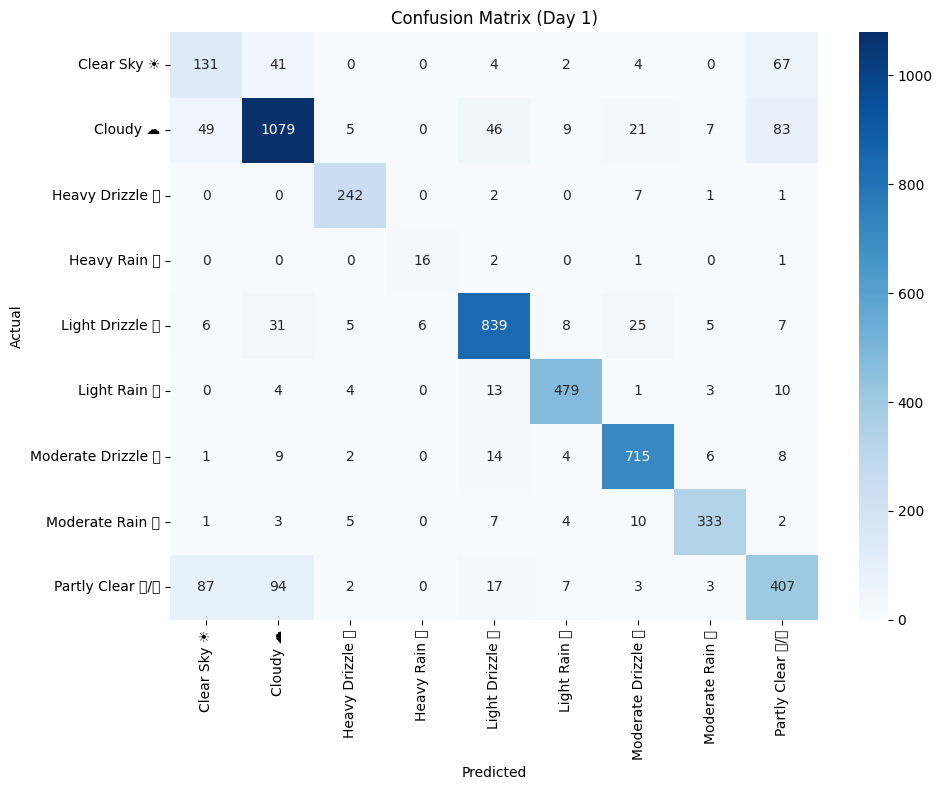


🎯 CLASS-TIER PERFORMANCE ANALYSIS:

MINORITY CLASSES:
----------------------------------------
  ✅ Moderate Drizzle 🌧  : P=0.909, R=0.942, F1=0.925, N=759.0
  ✅ Light Rain 🌦        : P=0.934, R=0.932, F1=0.933, N=514.0
  ✅ Moderate Rain 🌧     : P=0.930, R=0.912, F1=0.921, N=365.0
  ✅ Heavy Drizzle 🌧     : P=0.913, R=0.957, F1=0.934, N=253.0
  ✅ Heavy Rain 🌧        : P=0.727, R=0.800, F1=0.762, N=20.0

  📊 MINORITY AVERAGES:
     Precision: 0.8826
     Recall: 0.9086
     F1-Score: 0.8950

BALANCED CLASSES:
----------------------------------------
  ✅ Light Drizzle 🌦     : P=0.889, R=0.900, F1=0.894, N=932.0
  ✅ Clear Sky ☀️        : P=0.476, R=0.526, F1=0.500, N=249.0

  📊 BALANCED AVERAGES:
     Precision: 0.6826
     Recall: 0.7132
     F1-Score: 0.6972

MAJORITY CLASSES:
----------------------------------------
  ✅ Cloudy ☁️           : P=0.856, R=0.831, F1=0.843, N=1299.0
  ✅ Partly Clear 🌤/⛅    : P=0.695, R=0.656, F1=0.675, N=620.0

  📊 MAJORITY AVERAGES:
     Precision: 0.7751
 

In [5]:
def run_sliding_window_weather_forecasting(df, use_augmentation=True):
    """Run sliding window + rebalancing weather forecasting"""
    print("🌤️  SLIDING WINDOW + REBALANCING Weather Forecasting")
    print("=" * 60)
    
    # Initialize model
    model = ImprovedSlidingWindowModel(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data(target_col='weather_condition')
    
    # Train model with sliding window + rebalancing
    acc, daily_accs, history, y_true, y_pred = model.train_improved_model(use_augmentation=use_augmentation)
    
    print(f"\n🎯 FINAL RESULTS:")
    print(f"Overall Accuracy: {acc:.4f}")
    print(f"Average Daily Accuracy: {np.mean(daily_accs):.4f}")
    print(f"Best Day Accuracy: {max(daily_accs):.4f}")
    
    return model, acc, daily_accs, y_true, y_pred, history

# Usage:
model, acc, daily_accs, y_true, y_pred, history = run_sliding_window_weather_forecasting(df)



🔮 Making 3-day weather forecast...
----------------------------------------
📅 3-Day Weather Forecast:
  Thursday   (2025-05-01): Partly Clear 🌤/⛅ (confidence: 0.209)
  Friday     (2025-05-02): Cloudy ☁️ (confidence: 0.175)
  Saturday   (2025-05-03): Light Rain 🌦 (confidence: 0.230)


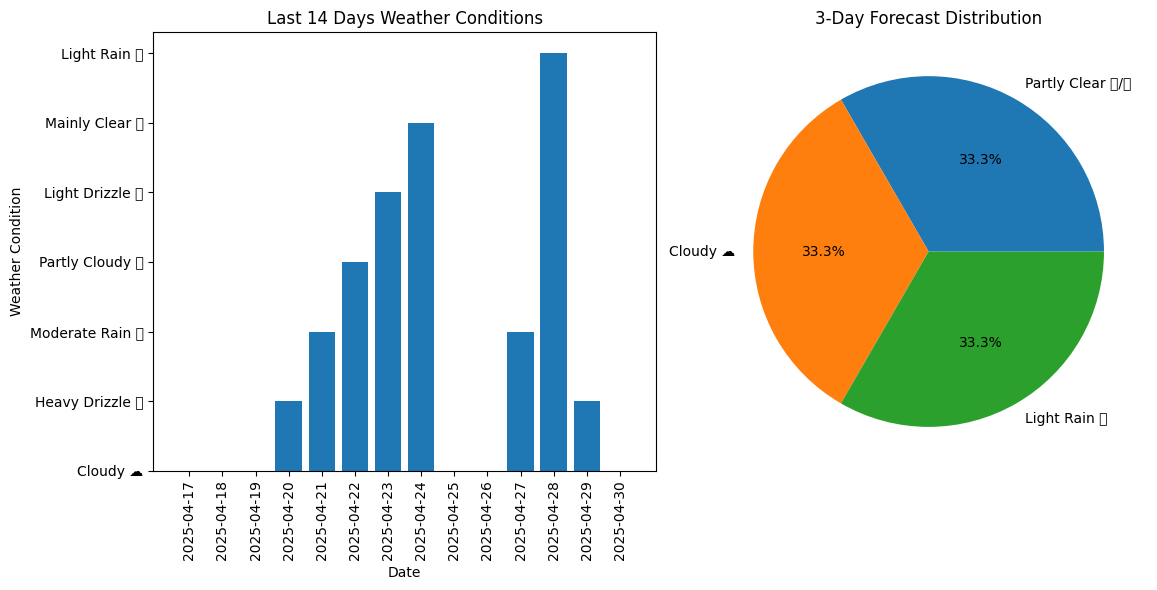

In [6]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations"""
    import matplotlib.pyplot as plt
    from datetime import timedelta

    
    print("\n🔮 Making 3-day weather forecast...")
    print("-" * 40)
    
    # Use the last 30 days of data for prediction
    feature_cols = [col for col in df.columns if col not in ['date', 'weather_condition', 'weather_condition_encoded']]
    recent_data = df[feature_cols].tail(30).values
    
    try:
        # Unpack the tuple returned by predict_next_week
        predicted_conditions, confidence_scores, uncertainties  = model.predict_next_week(recent_data)
        
        print("📅 3-Day Weather Forecast:")
        # Get last date in the dataset and generate next 7 dates
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]

        # Now iterate over individual predictions with their confidence scores
        for (day, date), condition, confidence in zip(days_and_dates, predicted_conditions, confidence_scores):
            print(f"  {day:10} ({date}): {condition} (confidence: {confidence:.3f})")
        
        # Create a simple visualization
        plt.figure(figsize=(12, 6))
    
        # Show recent actual labels with corresponding dates (last 30 days)
        recent_df = df[['date', 'weather_condition']].tail(14)
        recent_df['date'] = pd.to_datetime(recent_df['date'])

        plt.subplot(1, 2, 1)
        plt.bar(recent_df['date'].dt.strftime('%Y-%m-%d'), recent_df['weather_condition'].astype(str))
        plt.xticks(rotation=90)
        plt.title('Last 14 Days Weather Conditions')
        plt.xlabel('Date')
        plt.ylabel('Weather Condition')
        plt.tight_layout()

        plt.subplot(1, 2, 2)
        # Use predicted_conditions instead of next_week_forecast
        forecast_counts = pd.Series(predicted_conditions).value_counts()
        plt.pie(forecast_counts.values, labels=forecast_counts.index, autopct='%1.1f%%')
        plt.title('3-Day Forecast Distribution')
        
        plt.tight_layout()
        plt.show()
        
        return predicted_conditions, confidence_scores
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None, None

predictions, confidences = make_predictions_and_visualize(model, df)




IMPROVED SLIDING WINDOW + REBALANCING RESULTS
Overall Test Accuracy: 0.8529
Day 1 accuracy: 0.8463
Day 2 accuracy: 0.8609
Day 3 accuracy: 0.8513

Detailed Classification Report (Day 1):
----------------------------------------------------------------------
                    precision    recall  f1-score   support

      Clear Sky ☀️       0.48      0.53      0.50       249
         Cloudy ☁️       0.86      0.83      0.84      1299
   Heavy Drizzle 🌧       0.91      0.96      0.93       253
      Heavy Rain 🌧       0.73      0.80      0.76        20
   Light Drizzle 🌦       0.89      0.90      0.89       932
      Light Rain 🌦       0.93      0.93      0.93       514
Moderate Drizzle 🌧       0.91      0.94      0.92       759
   Moderate Rain 🌧       0.93      0.91      0.92       365
  Partly Clear 🌤/⛅       0.69      0.66      0.67       620

          accuracy                           0.85      5011
         macro avg       0.81      0.83      0.82      5011
      weighted avg  

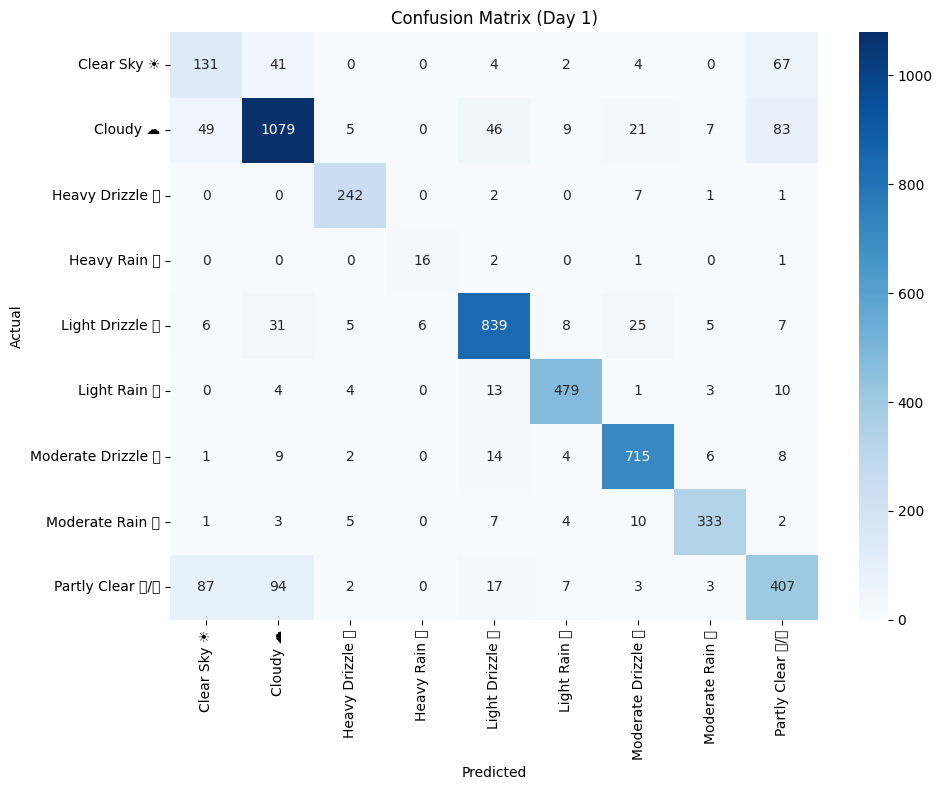


🎯 CLASS-TIER PERFORMANCE ANALYSIS:

MINORITY CLASSES:
----------------------------------------
  ✅ Moderate Drizzle 🌧  : P=0.909, R=0.942, F1=0.925, N=759.0
  ✅ Light Rain 🌦        : P=0.934, R=0.932, F1=0.933, N=514.0
  ✅ Moderate Rain 🌧     : P=0.930, R=0.912, F1=0.921, N=365.0
  ✅ Heavy Drizzle 🌧     : P=0.913, R=0.957, F1=0.934, N=253.0
  ✅ Heavy Rain 🌧        : P=0.727, R=0.800, F1=0.762, N=20.0

  📊 MINORITY AVERAGES:
     Precision: 0.8826
     Recall: 0.9086
     F1-Score: 0.8950

BALANCED CLASSES:
----------------------------------------
  ✅ Light Drizzle 🌦     : P=0.889, R=0.900, F1=0.894, N=932.0
  ✅ Clear Sky ☀️        : P=0.476, R=0.526, F1=0.500, N=249.0

  📊 BALANCED AVERAGES:
     Precision: 0.6826
     Recall: 0.7132
     F1-Score: 0.6972

MAJORITY CLASSES:
----------------------------------------
  ✅ Cloudy ☁️           : P=0.856, R=0.831, F1=0.843, N=1299.0
  ✅ Partly Clear 🌤/⛅    : P=0.695, R=0.656, F1=0.675, N=620.0

  📊 MAJORITY AVERAGES:
     Precision: 0.7751
 

In [7]:
overall_acc, daily_accuracies, history, y_true, y_pred = model.evaluate_improved_results(y_true, y_pred, history)

In [8]:
def show_weather_predictions(model, y_true, y_pred, num_samples=5):
    """Display actual vs predicted weather conditions in a readable format"""
    
    print("🌤️  WEATHER CONDITION PREDICTIONS")
    print("=" * 60)
    
    sample_size = min(num_samples, len(y_true))
    
    for i in range(sample_size):
        # Convert numeric predictions back to weather condition names
        actual_conditions = model.label_encoder.inverse_transform(y_true[i])
        pred_conditions = model.label_encoder.inverse_transform(y_pred[i])
        
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 40)
        
        # Create a nice table format
        print(f"{'Day':>5} | {'Actual Weather':^20} | {'Predicted Weather':^20} | {'Match':^6}")
        print("-" * 65)
        
        matches = 0
        for day in range(model.forecast_horizon):
            actual = actual_conditions[day]
            predicted = pred_conditions[day]
            match = "✅" if actual == predicted else "❌"
            if actual == predicted:
                matches += 1
                
            print(f"{day+1:>5} | {actual:^20} | {predicted:^20} | {match:^6}")
        
        accuracy = matches / model.forecast_horizon
        print("-" * 65)
        print(f"Sequence Accuracy: {matches}/{model.forecast_horizon} ({accuracy:.1%})")
        
    # Overall statistics
    print(f"\n📊 OVERALL STATISTICS:")
    print("=" * 40)
    
    total_predictions = y_true.size
    correct_predictions = np.sum(y_true == y_pred)
    overall_accuracy = correct_predictions / total_predictions
    
    print(f"Total Predictions: {total_predictions:,}")
    print(f"Correct Predictions: {correct_predictions:,}")
    print(f"Overall Accuracy: {overall_accuracy:.1%}")
    
    # Per-day accuracy
    print(f"\n📈 DAILY ACCURACY BREAKDOWN:")
    print("-" * 30)
    for day in range(model.forecast_horizon):
        day_correct = np.sum(y_true[:, day] == y_pred[:, day])
        day_total = len(y_true)
        day_accuracy = day_correct / day_total
        print(f"Day {day+1}: {day_accuracy:.1%} ({day_correct}/{day_total})")

# Usage:
show_weather_predictions(model, y_true, y_pred, num_samples=3)


🌤️  WEATHER CONDITION PREDICTIONS

📅 Test Sequence 1:
----------------------------------------
  Day |    Actual Weather    |  Predicted Weather   | Match 
-----------------------------------------------------------------
    1 |      Cloudy ☁️       |      Cloudy ☁️       |   ✅   
    2 |      Cloudy ☁️       |      Cloudy ☁️       |   ✅   
    3 |   Partly Clear 🌤/⛅   |      Cloudy ☁️       |   ❌   
-----------------------------------------------------------------
Sequence Accuracy: 2/3 (66.7%)

📅 Test Sequence 2:
----------------------------------------
  Day |    Actual Weather    |  Predicted Weather   | Match 
-----------------------------------------------------------------
    1 |   Moderate Rain 🌧    |   Moderate Rain 🌧    |   ✅   
    2 |   Moderate Rain 🌧    |   Moderate Rain 🌧    |   ✅   
    3 |   Light Drizzle 🌦    |   Light Drizzle 🌦    |   ✅   
-----------------------------------------------------------------
Sequence Accuracy: 3/3 (100.0%)

📅 Test Sequence 3:
---------

In [9]:
import os
import pickle
import joblib
from datetime import datetime
import json
import dill

def save_lstm_model(model, model_name="LSTM Model", save_dir="saved_models"):
    
    # Create save directory if it doesn't exist
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # Create a timestamp for uniqueness
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)
    
    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)
    
    try:
        # 1. Save the Keras model 
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print(f"✅ Keras model saved: keras_model.keras")
        
        # 2. Save the label encoder
        encoder_path = f"{model_folder}/label_encoder.pkl"
        with open(encoder_path, 'wb') as f:
            pickle.dump(model.label_encoder, f)
        print(f"✅ Label encoder saved: label_encoder.pkl")
        
        # 3. Save the scaler_X (if it exists)
        if hasattr(model, 'scaler_X') and model.scaler_X is not None:
            scaler_path = f"{model_folder}/scaler.pkl"
            joblib.dump(model.scaler_X, scaler_path)
            print(f"✅ Scaler saved: scaler.pkl")
        
        # 4. Save model configuration and metadata
        model_config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'feature_columns': getattr(model, 'feature_cols', []),
            'target_column': getattr(model, 'target_col', 'weather_condition'),
            'num_classes': len(model.label_encoder.classes_),
            'class_names': model.label_encoder.classes_.tolist(),
            'minority_classes': getattr(model, 'minority_classes', []),
            'timestamp': timestamp,
            'model_type': 'ImprovedSlidingWindowModel',
            'framework': 'TensorFlow/Keras'
        }
        
        config_path = f"{model_folder}/model_config.json"
        with open(config_path, 'w') as f:
            json.dump(model_config, f, indent=4)
        print(f"✅ Model configuration saved: model_config.json")
        
        # 5. Save essential attributes
        essential_attributes = {}
        safe_attributes = [
            'sequence_length', 'forecast_horizon', 'feature_cols',
            'target_col', 'minority_classes', 'is_trained'
        ]
        
        for attr in safe_attributes:
            if hasattr(model, attr):
                try:
                    pickle.dumps(getattr(model, attr))  # test if picklable
                    essential_attributes[attr] = getattr(model, attr)
                except Exception as e:
                    print(f"⚠️  Skipping unpicklable attribute '{attr}': {str(e)}")
        
        essential_model_path = f"{model_folder}/essential_attributes.pkl"
        try:
            with open(essential_model_path, 'wb') as f:
                pickle.dump(essential_attributes, f)
            print(f"✅ Essential attributes saved: essential_attributes.pkl")
        except Exception as e:
            print(f"⚠️  Regular pickle failed, trying with dill...")
            try:
                with open(essential_model_path, 'wb') as f:
                    dill.dump(essential_attributes, f)
                print(f"✅ Essential attributes saved with dill: essential_attributes.pkl")
            except Exception as e2:
                print(f"❌ Could not save model attributes: {str(e2)}")
        
        print(f"\n🎉 '{model_name}' successfully saved!")
        print(f"📁 Location: {model_folder}")
        print(f"📊 Model info: {len(model.label_encoder.classes_)} weather classes, {model.sequence_length}→{model.forecast_horizon} day forecast")
        
        return model_folder
        
    except Exception as e:
        print(f"❌ Error saving model: {str(e)}")
        return None


def load_lstm_model(model_folder):
    try:
        print(f"📂 Loading model from: {model_folder}")
        
        # Load configuration
        config_path = os.path.join(model_folder, "model_config.json")
        with open(config_path, 'r') as f:
            config = json.load(f)
        
        print(f"🔄 Loading '{config['model_name']}'...")

        # Load Keras model
        from tensorflow.keras.models import load_model
        keras_model = load_model(os.path.join(model_folder, "keras_model.keras"))
        print("✅ Keras model loaded")
        
        # Load label encoder
        with open(os.path.join(model_folder, "label_encoder.pkl"), 'rb') as f:
            label_encoder = pickle.load(f)
        print("✅ Label encoder loaded")
        
        # Load scaler_X if exists
        scaler_X = None
        scaler_path = os.path.join(model_folder, "scaler.pkl")
        if os.path.exists(scaler_path):
            scaler_X = joblib.load(scaler_path)
            print("✅ Scaler loaded")
        
        # Load essential attributes
        essential_attributes = {}
        essential_path = os.path.join(model_folder, "essential_attributes.pkl")
        if os.path.exists(essential_path):
            try:
                with open(essential_path, 'rb') as f:
                    essential_attributes = pickle.load(f)
                print("✅ Essential attributes loaded")
            except Exception:
                try:
                    with open(essential_path, 'rb') as f:
                        essential_attributes = dill.load(f)
                    print("✅ Essential attributes loaded with dill")
                except Exception as e2:
                    print(f"⚠️  Could not load essential attributes: {str(e2)}")
        
        print(f"\n🎉 Model components loaded successfully!")
        print(f"💡 Reconstruct your model class and assign these components.")
        
        return {
            'keras_model': keras_model,
            'label_encoder': label_encoder,
            'scaler_X': scaler_X,
            'config': config,
            'essential_attributes': essential_attributes
        }
        
    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")
        return None


model_folder = save_lstm_model(model, "WeatherModel2")

💾 Saving 'WeatherModel2' to: saved_models/WeatherModel2_20250707_001601
✅ Keras model saved: keras_model.keras
✅ Label encoder saved: label_encoder.pkl
✅ Scaler saved: scaler.pkl
✅ Model configuration saved: model_config.json
✅ Essential attributes saved: essential_attributes.pkl

🎉 'WeatherModel2' successfully saved!
📁 Location: saved_models/WeatherModel2_20250707_001601
📊 Model info: 9 weather classes, 10→3 day forecast


**Option3 : Predict the weather condition along side with the temp and humidity**

In [ ]:
class ImprovedSlidingWindowModel:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        """
        Improved sliding window + rebalancing model with multi-output forecasting
        """
        self.df = df.copy()
        self.forecast_horizon = forecast_horizon
        self.sequence_length = sequence_length
        self.scaler_X = None
        self.scaler_temp_humidity = None
        self.label_encoder = None
        self.model = None
        self.class_weights = None
        
        # Temperature and humidity column names
        self.temp_humidity_cols = [
            'temperature_2m_max (°C)', 
            'temperature_2m_min (°C)', 
            'relative_humidity_2m_max (%)', 
            'relative_humidity_2m_min (%)'
        ]
        
        # Improved thresholds for better balance
        self.minority_threshold = 0.08   # Very rare classes
        self.balanced_threshold = 0.20   # Medium frequency classes
        # Above 20% = majority classes
        
    def preprocess_data(self, target_col='weather_condition'):
        """Enhanced preprocessing with multi-output targets"""
        print("🧹 Enhanced preprocessing for multi-output forecasting...")
        df = self.df.copy()
        
        # Handle missing values for features
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col not in [target_col] + self.temp_humidity_cols:
                df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
                df[col] = df[col].interpolate(method='linear')
                df[col].fillna(df[col].median(), inplace=True)
        
        # Handle missing values for temperature and humidity targets
        for col in self.temp_humidity_cols:
            if col in df.columns:
                df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
                df[col] = df[col].interpolate(method='linear')
                df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with missing weather condition target
        df = df.dropna(subset=[target_col])
        
        # 🔄 Merge specific weather classes
        df[target_col] = df[target_col].replace({
            'Mainly Clear 🌤': 'Partly Clear 🌤/⛅',
            'Partly Cloudy ⛅': 'Partly Clear 🌤/⛅'
        })
        
        # Three-tier class analysis
        class_counts = df[target_col].value_counts()
        total_samples = len(df)
        print(f"Original class distribution:\n{class_counts}")
        print(f"Class percentages:\n{(class_counts/total_samples*100).round(2)}")
        
        # Categorize classes into three tiers
        self.minority_classes = []    # < 8%
        self.balanced_classes = []    # 8% - 20%  
        self.majority_classes = []    # > 20%
        
        for class_name, count in class_counts.items():
            percentage = count / total_samples
            if percentage < self.minority_threshold:
                self.minority_classes.append(class_name)
            elif percentage < self.balanced_threshold:
                self.balanced_classes.append(class_name)
            else:
                self.majority_classes.append(class_name)
        
        print(f"\nMinority classes (<{self.minority_threshold*100}%): {self.minority_classes}")
        print(f"Balanced classes ({self.minority_threshold*100}%-{self.balanced_threshold*100}%): {self.balanced_classes}")
        print(f"Majority classes (>{self.balanced_threshold*100}%): {self.majority_classes}")
        
        # Encode weather condition target
        self.label_encoder = LabelEncoder()
        df[target_col + '_encoded'] = self.label_encoder.fit_transform(df[target_col])
        
        # Feature engineering
        feature_cols = [col for col in df.columns if col not in ['date', target_col, target_col + '_encoded'] + self.temp_humidity_cols]
        
        # Add interaction features if temperature and humidity exist
        temp_col = next((col for col in df.columns if 'temperature' in col.lower() and col not in self.temp_humidity_cols), None)
        humidity_col = next((col for col in df.columns if 'humidity' in col.lower() and col not in self.temp_humidity_cols), None)
        
        if temp_col and humidity_col:
            df['temp_humidity_ratio'] = df[temp_col] / (df[humidity_col] + 1e-8)
            df['heat_index'] = df[temp_col] * (df[humidity_col] / 100)
            feature_cols.extend(['temp_humidity_ratio', 'heat_index'])
        
        # Scale features
        self.scaler_X = StandardScaler()
        df[feature_cols] = self.scaler_X.fit_transform(df[feature_cols])
        
        # Scale temperature and humidity targets separately
        available_temp_humidity_cols = [col for col in self.temp_humidity_cols if col in df.columns]
        if available_temp_humidity_cols:
            self.scaler_temp_humidity = StandardScaler()
            df[available_temp_humidity_cols] = self.scaler_temp_humidity.fit_transform(df[available_temp_humidity_cols])
        
        # Calculate class weights
        unique_classes = np.unique(df[target_col + '_encoded'])
        self.class_weights = compute_class_weight('balanced', classes=unique_classes, y=df[target_col + '_encoded'])
        self.class_weight_dict = dict(zip(unique_classes, self.class_weights))
        
        # Store processed data
        self.df = df
        self.feature_cols = feature_cols
        self.target_col = target_col + '_encoded'
        self.original_target_col = target_col
        self.available_temp_humidity_cols = available_temp_humidity_cols
        
        return df

    def create_improved_sliding_windows(self):
        """
        Improved sliding window strategy with multi-output targets
        """
        print(f"\n🪟 Creating improved sliding windows for multi-output forecasting...")
        
        X, y_weather, y_temp_humidity = [], [], []
        data = self.df
        features = data[self.feature_cols].values
        weather_target = data[self.target_col].values
        
        # Get temperature and humidity targets
        temp_humidity_targets = None
        if self.available_temp_humidity_cols:
            temp_humidity_targets = data[self.available_temp_humidity_cols].values
        
        # Get class IDs for each tier
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        balanced_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.balanced_classes 
                             if cls in self.label_encoder.classes_]
        majority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.majority_classes 
                             if cls in self.label_encoder.classes_]
        
        print(f"Minority class IDs: {minority_class_ids}")
        print(f"Balanced class IDs: {balanced_class_ids}")
        print(f"Majority class IDs: {majority_class_ids}")
        
        # Strategy 1: Intensive sampling for minority classes
        minority_windows = 0
        print("Creating intensive windows for minority classes...")
        
        for i in range(len(weather_target)):
            if weather_target[i] in minority_class_ids:
                # Create 7 overlapping windows around each minority event
                for offset in range(-3, 4):
                    start_idx = max(0, i - self.sequence_length + offset)
                    end_idx = start_idx + self.sequence_length + self.forecast_horizon
                    
                    if end_idx <= len(data):
                        X_seq = features[start_idx:start_idx + self.sequence_length]
                        y_weather_seq = weather_target[start_idx + self.sequence_length:end_idx]
                        
                        if temp_humidity_targets is not None:
                            y_temp_humidity_seq = temp_humidity_targets[start_idx + self.sequence_length:end_idx]
                        else:
                            y_temp_humidity_seq = np.zeros((self.forecast_horizon, 4))
                        
                        if len(X_seq) == self.sequence_length and len(y_weather_seq) == self.forecast_horizon:
                            X.append(X_seq)
                            y_weather.append(y_weather_seq)
                            y_temp_humidity.append(y_temp_humidity_seq)
                            minority_windows += 1
        
        # Strategy 2: Moderate sampling for balanced classes
        balanced_windows = 0
        print("Creating moderate windows for balanced classes...")
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, 2):
            y_weather_seq = weather_target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Check if sequence contains balanced classes
            if any(cls_id in balanced_class_ids for cls_id in y_weather_seq):
                X_seq = features[i:i + self.sequence_length]
                
                if temp_humidity_targets is not None:
                    y_temp_humidity_seq = temp_humidity_targets[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
                else:
                    y_temp_humidity_seq = np.zeros((self.forecast_horizon, 4))
                
                X.append(X_seq)
                y_weather.append(y_weather_seq)
                y_temp_humidity.append(y_temp_humidity_seq)
                balanced_windows += 1
        
        # Strategy 3: Controlled sampling for majority classes
        majority_windows = 0
        print("Creating controlled windows for majority classes...")
        
        # Calculate target number of majority windows (don't let them dominate)
        target_majority_windows = max(minority_windows * 1.5, balanced_windows * 0.8)
        
        majority_stride = max(3, int((len(data) - self.sequence_length - self.forecast_horizon) / target_majority_windows))
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, majority_stride):
            if majority_windows >= target_majority_windows:
                break
                
            y_weather_seq = weather_target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Only add if it's primarily majority class and we haven't hit our limit
            if all(cls_id in majority_class_ids for cls_id in y_weather_seq):
                X_seq = features[i:i + self.sequence_length]
                
                if temp_humidity_targets is not None:
                    y_temp_humidity_seq = temp_humidity_targets[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
                else:
                    y_temp_humidity_seq = np.zeros((self.forecast_horizon, 4))
                
                X.append(X_seq)
                y_weather.append(y_weather_seq)
                y_temp_humidity.append(y_temp_humidity_seq)
                majority_windows += 1
        
        # Strategy 4: Add transitional windows (sequences that show class changes)
        transition_windows = 0
        print("Adding transitional windows...")
        
        for i in range(len(weather_target) - self.forecast_horizon):
            current_class = weather_target[i]
            future_classes = weather_target[i+1:i+self.forecast_horizon+1]
            
            # Look for transitions from/to minority classes
            if (current_class in minority_class_ids or any(cls in minority_class_ids for cls in future_classes)):
                start_idx = max(0, i - self.sequence_length + 1)
                if start_idx + self.sequence_length + self.forecast_horizon <= len(data):
                    X_seq = features[start_idx:start_idx + self.sequence_length]
                    y_weather_seq = weather_target[start_idx + self.sequence_length:start_idx + self.sequence_length + self.forecast_horizon]
                    
                    if temp_humidity_targets is not None:
                        y_temp_humidity_seq = temp_humidity_targets[start_idx + self.sequence_length:start_idx + self.sequence_length + self.forecast_horizon]
                    else:
                        y_temp_humidity_seq = np.zeros((self.forecast_horizon, 4))
                    
                    if len(X_seq) == self.sequence_length and len(y_weather_seq) == self.forecast_horizon:
                        X.append(X_seq)
                        y_weather.append(y_weather_seq)
                        y_temp_humidity.append(y_temp_humidity_seq)
                        transition_windows += 1
        
        X = np.array(X)
        y_weather = np.array(y_weather)
        y_temp_humidity = np.array(y_temp_humidity)
        
        print(f"\nWindow creation results:")
        print(f"Minority class windows: {minority_windows}")
        print(f"Balanced class windows: {balanced_windows}")
        print(f"Majority class windows: {majority_windows}")
        print(f"Transition windows: {transition_windows}")
        print(f"Total windows: {len(X)}")
        print(f"Multi-output shapes: Weather={y_weather.shape}, TempHumidity={y_temp_humidity.shape}")
        
        # Analyze final distribution
        final_dist = Counter(y_weather.flatten())
        total_predictions = len(y_weather.flatten())
        print(f"\nFinal class distribution:")
        for class_id, count in sorted(final_dist.items()):
            class_name = self.label_encoder.inverse_transform([class_id])[0]
            percentage = (count / total_predictions) * 100
            print(f"  {class_name}: {count} ({percentage:.1f}%)")
        
        return X, y_weather, y_temp_humidity
    
    def add_targeted_augmentation(self, X, y_weather, y_temp_humidity, augment_factor=1):
        """
        Add targeted augmentation specifically for minority classes (multi-output)
        """
        print(f"\n🔄 Adding targeted augmentation for minority classes...")
        
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        
        X_aug = list(X)
        y_weather_aug = list(y_weather)
        y_temp_humidity_aug = list(y_temp_humidity)
        augmented_count = 0
        
        for i in range(len(X)):
            # Check if sequence contains minority classes
            if any(cls_id in minority_class_ids for cls_id in y_weather[i]):
                for _ in range(augment_factor):
                    # Add controlled noise to features
                    noise_scale = 0.01  # Very small noise
                    noise = np.random.normal(0, noise_scale, X[i].shape)
                    X_noisy = X[i] + noise
                    
                    # Add small temporal shifts occasionally
                    if np.random.random() < 0.3:
                        shift = np.random.randint(-1, 2)
                        if shift != 0:
                            X_shifted = np.roll(X[i], shift, axis=0)
                            X_aug.append(X_shifted)
                        else:
                            X_aug.append(X_noisy)
                    else:
                        X_aug.append(X_noisy)
                    
                    y_weather_aug.append(y_weather[i])
                    y_temp_humidity_aug.append(y_temp_humidity[i])
                    augmented_count += 1
        
        print(f"Added {augmented_count} augmented sequences for minority classes")
        return np.array(X_aug), np.array(y_weather_aug), np.array(y_temp_humidity_aug)
    
    def focal_loss(self, alpha=0.25, gamma=2.0):
        """
        Focal loss implementation for handling class imbalance
        """
        def focal_loss_fn(y_true, y_pred):
            epsilon = K.epsilon()
            y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
            
            # Cross entropy
            ce = -y_true * K.log(y_pred)
            
            # Focal weight: (1-p)^gamma
            p_t = K.sum(y_true * y_pred, axis=-1, keepdims=True)
            focal_weight = K.pow((1 - p_t), gamma)
            
            # Alpha weighting
            alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
            
            # Final focal loss
            focal_loss = alpha_t * focal_weight * ce
            
            return K.mean(K.sum(focal_loss, axis=-1))
        
        return focal_loss_fn
    
    def build_enhanced_model(self, input_shape, num_classes, num_temp_humidity_features):
        """
        Build enhanced multi-output LSTM model with fixed layer naming
        """
        # Input layer
        inputs = Input(shape=input_shape)
        
        # Shared LSTM layers
        lstm1 = LSTM(256, return_sequences=True, 
                     kernel_regularizer=l2(0.001), 
                     dropout=0.2, recurrent_dropout=0.2)(inputs)
        lstm1_bn = BatchNormalization()(lstm1)
        
        lstm2 = LSTM(128, return_sequences=True,
                     kernel_regularizer=l2(0.001),
                     dropout=0.2, recurrent_dropout=0.2)(lstm1_bn)
        lstm2_bn = BatchNormalization()(lstm2)
        
        lstm3 = LSTM(64, return_sequences=False,
                     kernel_regularizer=l2(0.001),
                     dropout=0.2, recurrent_dropout=0.2)(lstm2_bn)
        lstm3_bn = BatchNormalization()(lstm3)
        lstm3_drop = Dropout(0.3)(lstm3_bn)
        
        # Shared dense layer
        shared_dense = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(lstm3_drop)
        shared_dense_bn = BatchNormalization()(shared_dense)
        shared_dense_drop = Dropout(0.3)(shared_dense_bn)
        
        # Weather condition output branch
        weather_dense1 = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(shared_dense_drop)
        weather_dense1_bn = BatchNormalization()(weather_dense1)
        weather_dense1_drop = Dropout(0.4)(weather_dense1_bn)
        
        weather_dense2 = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(weather_dense1_drop)
        weather_dense2_drop = Dropout(0.3)(weather_dense2)
        
        weather_dense3 = Dense(64, activation='relu')(weather_dense2_drop)
        weather_dense3_drop = Dropout(0.2)(weather_dense3)
        
        # Weather output (classification) - FIXED: Set name properly
        weather_output_flat = Dense(self.forecast_horizon * num_classes, activation='softmax')(weather_dense3_drop)
        weather_output = tf.keras.layers.Reshape((self.forecast_horizon, num_classes), name='weather_output')(weather_output_flat)
        
        # Temperature and humidity output branch
        temp_humidity_dense1 = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(shared_dense_drop)
        temp_humidity_dense1_bn = BatchNormalization()(temp_humidity_dense1)
        temp_humidity_dense1_drop = Dropout(0.3)(temp_humidity_dense1_bn)
        
        temp_humidity_dense2 = Dense(64, activation='relu')(temp_humidity_dense1_drop)
        temp_humidity_dense2_drop = Dropout(0.2)(temp_humidity_dense2)
        
        # Temperature and humidity output (regression) - FIXED: Set name properly
        temp_humidity_output_flat = Dense(self.forecast_horizon * num_temp_humidity_features, activation='linear')(temp_humidity_dense2_drop)
        temp_humidity_output = tf.keras.layers.Reshape((self.forecast_horizon, num_temp_humidity_features), name='temp_humidity_output')(temp_humidity_output_flat)
        
        # Create the model
        model = Model(inputs=inputs, outputs=[weather_output, temp_humidity_output])
        
        return model
    
    def train_improved_model(self, use_augmentation=True):
        """
        Train the improved multi-output sliding window model
        """
        print("\n" + "="*70)
        print("TRAINING IMPROVED MULTI-OUTPUT SLIDING WINDOW + REBALANCING MODEL")
        print("="*70)
        
        # Create improved sliding windows
        X, y_weather, y_temp_humidity = self.create_improved_sliding_windows()
        
        # Add targeted augmentation if requested
        if use_augmentation:
            X, y_weather, y_temp_humidity = self.add_targeted_augmentation(X, y_weather, y_temp_humidity, augment_factor=1)
        
        num_classes = len(self.label_encoder.classes_)
        num_temp_humidity_features = len(self.available_temp_humidity_cols) if self.available_temp_humidity_cols else 4
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        print(f"\nFinal training data: X={X.shape}, y_weather={y_weather.shape}, y_temp_humidity={y_temp_humidity.shape}")
        print(f"Number of weather classes: {num_classes}")
        print(f"Number of temp/humidity features: {num_temp_humidity_features}")
        
        # Convert weather to categorical
        y_weather_onehot = to_categorical(y_weather, num_classes=num_classes)
        
        # Stratified train-test split
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(sss.split(X, y_weather[:, 0]))
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_weather_train, y_weather_test = y_weather_onehot[train_idx], y_weather_onehot[test_idx]
        y_temp_humidity_train, y_temp_humidity_test = y_temp_humidity[train_idx], y_temp_humidity[test_idx]
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build and compile model
        self.model = self.build_enhanced_model((self.sequence_length, X.shape[2]), num_classes, num_temp_humidity_features)
        
        # FIXED: Print model output names to verify
        print(f"Model output names: {[output.name for output in self.model.outputs]}")
        
        # Compile with multiple outputs
        self.model.compile(
            optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
            loss={
                'weather_output': self.focal_loss(alpha=0.25, gamma=2.0),
                'temp_humidity_output': 'mse'
            },
            loss_weights={
                'weather_output': 1.0,
                'temp_humidity_output': 0.5  # Weight regression loss less than classification
            },
            metrics={
                'weather_output': 'accuracy',
                'temp_humidity_output': 'mae'
            }
        )
        
        # Enhanced callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print("\nTraining improved multi-output model...")
        history = self.model.fit(
            X_train, 
            {
                'weather_output': y_weather_train,
                'temp_humidity_output': y_temp_humidity_train
            },
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print("\nEvaluating improved multi-output model...")
        predictions = self.model.predict(X_test, verbose=0)
        y_weather_pred_prob = predictions[0]
        y_temp_humidity_pred = predictions[1]
        
        y_weather_pred = np.argmax(y_weather_pred_prob, axis=-1)
        y_weather_true = np.argmax(y_weather_test, axis=-1)
        
        return self.evaluate_improved_results(y_weather_true, y_weather_pred, y_temp_humidity_test, y_temp_humidity_pred, history)
 
    def evaluate_improved_results(self, y_weather_true, y_weather_pred, y_temp_humidity_true, y_temp_humidity_pred, history):
        """
        Comprehensive evaluation with multi-output analysis
        """
        print("\n" + "="*70)
        print("IMPROVED MULTI-OUTPUT SLIDING WINDOW + REBALANCING RESULTS")
        print("="*70)
        
        # Weather condition evaluation
        print("\n🌤️  WEATHER CONDITION RESULTS:")
        print("="*50)
        
        # Overall accuracy
        overall_acc = accuracy_score(y_weather_true.flatten(), y_weather_pred.flatten())
        print(f"Overall Weather Accuracy: {overall_acc:.4f}")
        
        # Daily accuracies
        daily_accuracies = []
        for day in range(self.forecast_horizon):
            day_acc = accuracy_score(y_weather_true[:, day], y_weather_pred[:, day])
            daily_accuracies.append(day_acc)
            print(f"Day {day+1} weather accuracy: {day_acc:.4f}")
        
        # Detailed classification report for Day 1
        print(f"\nDetailed Weather Classification Report (Day 1):")
        print("-" * 70)
        target_names = self.label_encoder.classes_
        report = classification_report(y_weather_true[:, 0], y_weather_pred[:, 0], 
                                     target_names=target_names, 
                                     zero_division=0,
                                     output_dict=True)
        print(classification_report(y_weather_true[:, 0], y_weather_pred[:, 0], 
                                  target_names=target_names, 
                                  zero_division=0))
        
        # Temperature and humidity evaluation
        print("\n🌡️  TEMPERATURE & HUMIDITY RESULTS:")
        print("="*50)
        
        # Calculate metrics for each temp/humidity feature
        temp_humidity_metrics = {}
        feature_names = self.available_temp_humidity_cols if self.available_temp_humidity_cols else ['temp_max', 'temp_min', 'humidity_max', 'humidity_min']
        
        for i, feature_name in enumerate(feature_names[:y_temp_humidity_true.shape[2]]):
            mae_values = []
            rmse_values = []
            
            for day in range(self.forecast_horizon):
                y_true_day = y_temp_humidity_true[:, day, i]
                y_pred_day = y_temp_humidity_pred[:, day, i]
                
                mae = mean_absolute_error(y_true_day, y_pred_day)
                rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
                
                mae_values.append(mae)
                rmse_values.append(rmse)
            
            temp_humidity_metrics[feature_name] = {
                'mae': mae_values,
                'rmse': rmse_values,
                'avg_mae': np.mean(mae_values),
                'avg_rmse': np.mean(rmse_values)
            }
            
            print(f"\n{feature_name}:")
            for day in range(self.forecast_horizon):
                print(f"  Day {day+1}: MAE={mae_values[day]:.3f}, RMSE={rmse_values[day]:.3f}")
            print(f"  Average: MAE={np.mean(mae_values):.3f}, RMSE={np.mean(rmse_values):.3f}")
        
        # Class-tier performance analysis (same as before)
        print(f"\n🎯 WEATHER CLASS-TIER PERFORMANCE ANALYSIS:")
        print("="*70)
        
        for tier_name, class_list in [
            ("MINORITY", self.minority_classes),
            ("BALANCED", self.balanced_classes), 
            ("MAJORITY", self.majority_classes)
        ]:
            print(f"\n{tier_name} CLASSES:")
            print("-" * 40)
            tier_f1_scores = []
            tier_recalls = []
            tier_precisions = []
            
            for class_name in class_list:
                if class_name in report:
                    metrics = report[class_name]
                    f1 = metrics['f1-score']
                    precision = metrics['precision']
                    recall = metrics['recall']
                    support = metrics['support']
                    
                    tier_f1_scores.append(f1)
                    tier_recalls.append(recall)
                    tier_precisions.append(precision)
                    
                    status = "✅" if f1 > 0.3 else "⚠️" if f1 > 0.1 else "❌"
                    print(f"  {status} {class_name:20s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
            
            if tier_f1_scores:
                avg_f1 = np.mean(tier_f1_scores)
                avg_precision = np.mean(tier_precisions)
                avg_recall = np.mean(tier_recalls)
                print(f"\n  📊 {tier_name} AVERAGES:")
                print(f"     Precision: {avg_precision:.4f}")
                print(f"     Recall: {avg_recall:.4f}")
                print(f"     F1-Score: {avg_f1:.4f}")
        
        # Problem class identification
        print(f"\n⚠️  WEATHER CLASSES STILL STRUGGLING (F1 < 0.2):")
        print("-" * 50)
        struggling_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] < 0.2:
                struggling_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ❌ {class_name}: F1={f1:.3f}, N={support}")
        
        if not struggling_classes:
            print("  🎉 No classes with F1 < 0.2!")
        
        # Success stories
        print(f"\n🎉 BIGGEST WEATHER IMPROVEMENTS (F1 > 0.5):")
        print("-" * 50)
        success_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] > 0.5:
                success_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ✅ {class_name}: F1={f1:.3f}, N={support}")
        
        return overall_acc, daily_accuracies, temp_humidity_metrics, history, y_weather_true, y_weather_pred, y_temp_humidity_true, y_temp_humidity_pred
    
    def predict_next_week(self, recent_data):
        """
        Enhanced multi-output prediction with confidence analysis
        """
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_X.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_X.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be either a DataFrame or numpy array")
        
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        predictions = self.model.predict(input_seq, verbose=0)
        
        # Weather predictions
        weather_pred_prob = predictions[0][0]
        weather_pred_classes = np.argmax(weather_pred_prob, axis=-1)
        predicted_conditions = self.label_encoder.inverse_transform(weather_pred_classes)
        weather_confidence_scores = np.max(weather_pred_prob, axis=-1)
        
        # Calculate prediction uncertainty for weather
        weather_entropy = -np.sum(weather_pred_prob * np.log(weather_pred_prob + 1e-8), axis=-1)
        normalized_weather_entropy = weather_entropy / np.log(len(self.label_encoder.classes_))
        
        # Temperature and humidity predictions
        temp_humidity_pred = predictions[1][0]
        
        # Inverse transform if scaler was used
        if self.scaler_temp_humidity is not None and self.available_temp_humidity_cols:
            temp_humidity_pred_original = []
            for day in range(self.forecast_horizon):
                # Create a temporary array with the right shape for inverse transform
                temp_array = np.zeros((1, len(self.available_temp_humidity_cols)))
                temp_array[0, :len(self.available_temp_humidity_cols)] = temp_humidity_pred[day, :len(self.available_temp_humidity_cols)]
                temp_inverted = self.scaler_temp_humidity.inverse_transform(temp_array)
                temp_humidity_pred_original.append(temp_inverted[0])
            temp_humidity_pred_original = np.array(temp_humidity_pred_original)
        else:
            temp_humidity_pred_original = temp_humidity_pred
        
        # Create prediction results dictionary
        prediction_results = {
            'weather_conditions': predicted_conditions,
            'weather_confidence': weather_confidence_scores,
            'weather_uncertainty': normalized_weather_entropy,
            'temperature_humidity': temp_humidity_pred_original,
            'feature_names': self.available_temp_humidity_cols if self.available_temp_humidity_cols else ['temp_max', 'temp_min', 'humidity_max', 'humidity_min']
        }
        
        return prediction_results


In [5]:
def run_sliding_window_weather_forecasting(df, use_augmentation=True):
    """Run multi-output sliding window + rebalancing weather forecasting"""
    print("🌤️  MULTI-OUTPUT SLIDING WINDOW + REBALANCING Weather Forecasting")
    print("=" * 70)
    
    # Initialize model
    model = ImprovedSlidingWindowModel(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data(target_col='weather_condition')
    
    # Train model with multi-output sliding window + rebalancing
    acc, daily_accs, temp_humidity_metrics, history, y_weather_true, y_weather_pred, y_temp_humidity_true, y_temp_humidity_pred = model.train_improved_model(use_augmentation=use_augmentation)
    
    print(f"\n🎯 FINAL RESULTS:")
    print("="*50)
    print(f"Weather Overall Accuracy: {acc:.4f}")
    print(f"Weather Average Daily Accuracy: {np.mean(daily_accs):.4f}")
    print(f"Weather Best Day Accuracy: {max(daily_accs):.4f}")
    
    print(f"\nTemperature & Humidity Summary:")
    for feature_name, metrics in temp_humidity_metrics.items():
        print(f"  {feature_name}: Avg MAE={metrics['avg_mae']:.3f}, Avg RMSE={metrics['avg_rmse']:.3f}")
    
    return model, acc, daily_accs, temp_humidity_metrics, y_weather_true, y_weather_pred, y_temp_humidity_true, y_temp_humidity_pred, history

# Usage:
model, acc, daily_accs, temp_humidity_metrics, y_weather_true, y_weather_pred, y_temp_humidity_true, y_temp_humidity_pred, history = run_sliding_window_weather_forecasting(df)

🌤️  MULTI-OUTPUT SLIDING WINDOW + REBALANCING Weather Forecasting
🧹 Enhanced preprocessing for multi-output forecasting...
Original class distribution:
weather_condition
Cloudy ☁️             3403
Partly Clear 🌤/⛅      1998
Light Drizzle 🌦       1347
Clear Sky ☀️          1251
Moderate Drizzle 🌧     522
Light Rain 🌦           330
Moderate Rain 🌧        218
Heavy Drizzle 🌧        170
Heavy Rain 🌧            13
Name: count, dtype: int64
Class percentages:
weather_condition
Cloudy ☁️             36.78
Partly Clear 🌤/⛅      21.60
Light Drizzle 🌦       14.56
Clear Sky ☀️          13.52
Moderate Drizzle 🌧     5.64
Light Rain 🌦           3.57
Moderate Rain 🌧        2.36
Heavy Drizzle 🌧        1.84
Heavy Rain 🌧           0.14
Name: count, dtype: float64

Minority classes (<8.0%): ['Moderate Drizzle 🌧', 'Light Rain 🌦', 'Moderate Rain 🌧', 'Heavy Drizzle 🌧', 'Heavy Rain 🌧']
Balanced classes (8.0%-20.0%): ['Light Drizzle 🌦', 'Clear Sky ☀️']
Majority classes (>20.0%): ['Cloudy ☁️', 'Partly Clear 🌤/

In [10]:
def create_features(df):
    df = df.copy()
    df['temp_humidity_ratio'] = df['relative_humidity_2m_max (%)'] / (df['relative_humidity_2m_min (%)'] + 1e-5)
    df['heat_index'] = 0.5 * (df['temperature_2m_max (°C)'] + df['temperature_2m_min (°C)'])
    return df

df = create_features(df)



🔮 Making 3-day weather forecast with temperature and humidity...
--------------------------------------------------
📅 3-Day Forecast Summary:
  Thursday   (2025-05-01):
     ☁️ Weather: Cloudy ☁️ (confidence: 0.239)
     🌡️ temperature_2m_max (°C): 31.58
     🌡️ temperature_2m_min (°C): 20.33
     🌡️ relative_humidity_2m_max (%): 90.72
     🌡️ relative_humidity_2m_min (%): 37.33
  Friday     (2025-05-02):
     ☁️ Weather: Cloudy ☁️ (confidence: 0.251)
     🌡️ temperature_2m_max (°C): 32.25
     🌡️ temperature_2m_min (°C): 20.58
     🌡️ relative_humidity_2m_max (%): 90.28
     🌡️ relative_humidity_2m_min (%): 35.37
  Saturday   (2025-05-03):
     ☁️ Weather: Cloudy ☁️ (confidence: 0.260)
     🌡️ temperature_2m_max (°C): 32.51
     🌡️ temperature_2m_min (°C): 20.82
     🌡️ relative_humidity_2m_max (%): 89.91
     🌡️ relative_humidity_2m_min (%): 35.09


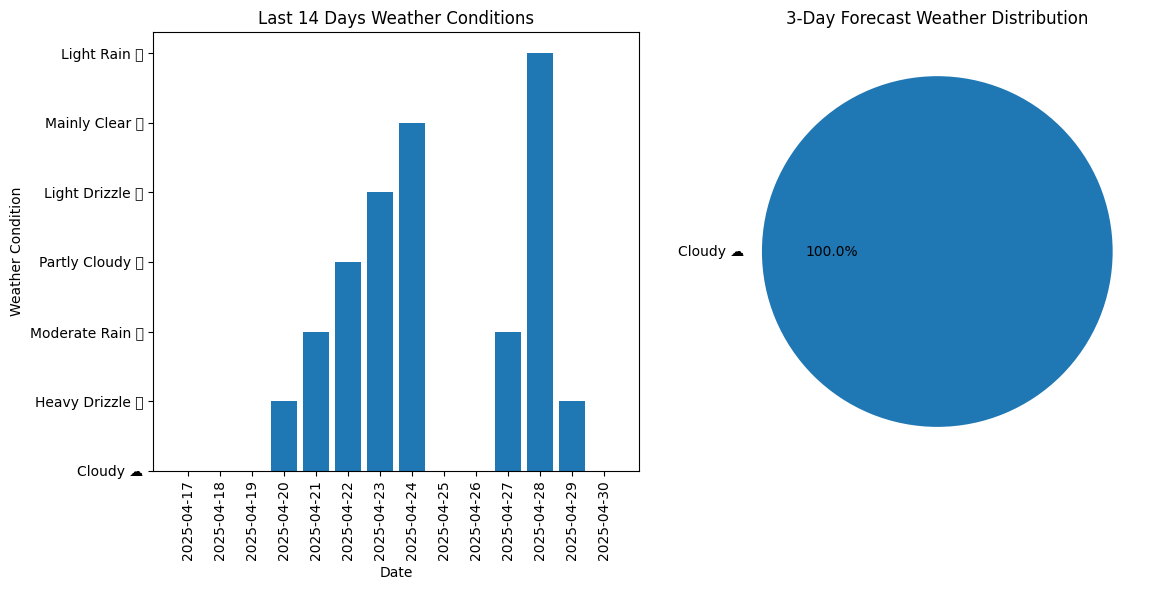

In [11]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations for weather and temperature/humidity"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    import pandas as pd
    
    print("\n🔮 Making 3-day weather forecast with temperature and humidity...")
    print("-" * 50)
    
    # Get only the features used during training
    feature_cols = model.feature_cols  # model.feature_cols should match what was used in training

    # Pull only the last `sequence_length` rows
    recent_data = df[feature_cols].tail(model.sequence_length).copy()

    # Ensure numeric and same dtype
    recent_data = recent_data.apply(pd.to_numeric, errors='coerce').dropna()

    # If any rows dropped, re-pad from the top
    if len(recent_data) < model.sequence_length:
        padding_needed = model.sequence_length - len(recent_data)
        padding = np.zeros((padding_needed, len(feature_cols)))
        recent_data = np.vstack([padding, recent_data.values])
    else:
        recent_data = recent_data.values

    # Final shape must be (1, sequence_length, num_features)
    recent_data = recent_data.reshape(1, model.sequence_length, len(feature_cols)).astype(np.float32)


    
    try:
        # Get full prediction result dictionary
        prediction_results = model.predict_next_week(recent_data)
        predicted_conditions = prediction_results['weather_conditions']
        confidence_scores = prediction_results['weather_confidence']
        uncertainties = prediction_results['weather_uncertainty']
        temp_humidity_preds = prediction_results['temperature_humidity']
        feature_names = prediction_results['feature_names']
        
        # Get next 3 days
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        print("📅 3-Day Forecast Summary:")
        for i, ((day, date), condition, confidence, temp_hum) in enumerate(zip(days_and_dates, predicted_conditions, confidence_scores, temp_humidity_preds)):
            print(f"  {day:10} ({date}):")
            print(f"     ☁️ Weather: {condition} (confidence: {confidence:.3f})")
            for j, fname in enumerate(feature_names):
                print(f"     🌡️ {fname}: {temp_hum[j]:.2f}")
        
        # Visualization
        plt.figure(figsize=(12, 6))
        
        # Plot recent weather conditions
        recent_df = df[['date', 'weather_condition']].tail(14)
        recent_df['date'] = pd.to_datetime(recent_df['date'])
        plt.subplot(1, 2, 1)
        plt.bar(recent_df['date'].dt.strftime('%Y-%m-%d'), recent_df['weather_condition'].astype(str))
        plt.xticks(rotation=90)
        plt.title('Last 14 Days Weather Conditions')
        plt.xlabel('Date')
        plt.ylabel('Weather Condition')
        
        # Plot forecast distribution
        plt.subplot(1, 2, 2)
        forecast_counts = pd.Series(predicted_conditions[:3]).value_counts()
        plt.pie(forecast_counts.values, labels=forecast_counts.index, autopct='%1.1f%%')
        plt.title('3-Day Forecast Weather Distribution')
        
        plt.tight_layout()
        plt.show()
        
        return predicted_conditions, confidence_scores, temp_humidity_preds
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None, None, None


predictions, confidences, temp_humidity = make_predictions_and_visualize(model, df)


In [15]:
def evaluate_results(self, y_true, y_pred, y_temp_true=None, y_temp_pred=None, history=None):
    """Evaluate both classification and regression outputs (if available)."""
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error, mean_squared_error

    print("\n" + "="*70)
    print("📈 EVALUATING MULTI-OUTPUT MODEL (Weather + Temp/Humidity)")
    print("="*70)

    # -------------------------------
    # WEATHER CLASSIFICATION SECTION
    # -------------------------------
    print("\n🌦️ WEATHER CLASSIFICATION RESULTS")
    print("-" * 60)

    overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
    print(f"✅ Overall Accuracy: {overall_acc:.4f}")

    daily_accuracies = []
    for day in range(self.forecast_horizon):
        acc = accuracy_score(y_true[:, day], y_pred[:, day])
        daily_accuracies.append(acc)
        print(f"  Day {day+1} Accuracy: {acc:.4f}")

    target_names = self.label_encoder.classes_
    report = classification_report(
        y_true[:, 0], y_pred[:, 0],
        target_names=target_names,
        output_dict=True, zero_division=0
    )
    print("\n📊 Classification Report (Day 1):")
    print(classification_report(
        y_true[:, 0], y_pred[:, 0],
        target_names=target_names, zero_division=0
    ))

    # -------------------------------
    # TEMPERATURE/HUMIDITY REGRESSION SECTION
    # -------------------------------
    if y_temp_true is not None and y_temp_pred is not None:
        print("\n🌡️ TEMPERATURE & HUMIDITY REGRESSION RESULTS")
        print("-" * 60)

        num_days = y_temp_true.shape[1]
        num_features = y_temp_true.shape[2]

        global_mae = []
        global_rmse = []

        for f in range(num_features):
            mae = mean_absolute_error(y_temp_true[:, :, f], y_temp_pred[:, :, f])
            rmse = mean_squared_error(y_temp_true[:, :, f], y_temp_pred[:, :, f], squared=False)
            global_mae.append(mae)
            global_rmse.append(rmse)
            feature_name = self.available_temp_humidity_cols[f] if self.available_temp_humidity_cols else f"Feature {f}"
            print(f"  📌 {feature_name}: MAE={mae:.3f}, RMSE={rmse:.3f}")

        # Plot MAE/RMSE bar charts
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        feature_labels = self.available_temp_humidity_cols if self.available_temp_humidity_cols else [f"Feature {i}" for i in range(num_features)]

        ax[0].bar(feature_labels, global_mae, color='orange')
        ax[0].set_title("Mean Absolute Error per Feature")
        ax[0].set_ylabel("MAE")
        ax[0].set_ylim(0, max(global_mae) * 1.2)

        ax[1].bar(feature_labels, global_rmse, color='green')
        ax[1].set_title("Root Mean Squared Error per Feature")
        ax[1].set_ylabel("RMSE")
        ax[1].set_ylim(0, max(global_rmse) * 1.2)

        plt.tight_layout()
        plt.show()

    # -------------------------------
    # SAMPLE VISUALIZATION SECTION
    # -------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    x_pos = np.arange(self.forecast_horizon)
    width = 0.35

    # 1. Daily Accuracy Bar Plot
    axes[0, 0].bar(range(1, self.forecast_horizon + 1), daily_accuracies, color='skyblue')
    axes[0, 0].set_title('Accuracy by Forecast Day')
    axes[0, 0].set_xlabel('Day')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_ylim(0, 1)

    # 2. Confusion Matrix (Day 1)
    cm = confusion_matrix(y_true[:, 0], y_pred[:, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=axes[0, 1])
    axes[0, 1].set_title('Confusion Matrix (Day 1)')
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')

    # 3 & 4. Prediction vs Actual for 2 Sample Sequences
    for i in range(min(2, len(y_true))):
        ax_idx = (1, 0) if i == 0 else (1, 1)
        axes[ax_idx].bar(x_pos - width/2, y_true[i], width, label='Actual', alpha=0.7)
        axes[ax_idx].bar(x_pos + width/2, y_pred[i], width, label='Predicted', alpha=0.7)
        axes[ax_idx].set_title(f'Prediction vs Actual - Sequence {i+1}')
        axes[ax_idx].set_xticks(x_pos)
        axes[ax_idx].set_xticklabels([f'Day {d+1}' for d in x_pos])
        axes[ax_idx].set_xlabel('Day')
        axes[ax_idx].set_ylabel('Weather Code')
        axes[ax_idx].legend()

    plt.tight_layout()
    plt.show()

    # Print Sample Class Predictions
    print(f"\n📄 Sample Predictions:")
    for i in range(min(3, len(y_true))):
        actual = self.label_encoder.inverse_transform(y_true[i])
        predicted = self.label_encoder.inverse_transform(y_pred[i])
        print(f"\nSequence {i+1}:")
        for d in range(self.forecast_horizon):
            print(f"  Day {d+1}: Actual = '{actual[d]}', Predicted = '{predicted[d]}'")

    return overall_acc, daily_accuracies, history, y_true, y_pred


overall_acc, daily_accuracies, temp_humidity_metrics, history, y_weather_true, y_weather_pred, y_temp_humidity_true, y_temp_humidity_pred = model.evaluate_improved_results(
    y_weather_true, y_weather_pred,
    y_temp_humidity_true, y_temp_humidity_pred,
    history
)



IMPROVED MULTI-OUTPUT SLIDING WINDOW + REBALANCING RESULTS

🌤️  WEATHER CONDITION RESULTS:
Overall Weather Accuracy: 0.7599
Day 1 weather accuracy: 0.7507
Day 2 weather accuracy: 0.7841
Day 3 weather accuracy: 0.7450

Detailed Weather Classification Report (Day 1):
----------------------------------------------------------------------
                    precision    recall  f1-score   support

      Clear Sky ☀️       0.49      0.37      0.42       249
         Cloudy ☁️       0.78      0.80      0.79      1299
   Heavy Drizzle 🌧       1.00      0.06      0.10       253
      Heavy Rain 🌧       0.67      0.60      0.63        20
   Light Drizzle 🌦       0.90      0.90      0.90       932
      Light Rain 🌦       0.83      0.85      0.84       514
Moderate Drizzle 🌧       0.72      0.90      0.80       759
   Moderate Rain 🌧       0.78      0.87      0.82       365
  Partly Clear 🌤/⛅       0.52      0.53      0.52       620

          accuracy                           0.75      5011


🌤️  WEATHER CONDITION PREDICTIONS

📅 Test Sequence 1:
----------------------------------------
  Day |    Actual Weather    |  Predicted Weather   | Match 
-----------------------------------------------------------------
    1 |      Cloudy ☁️       |      Cloudy ☁️       |   ✅   
    2 |      Cloudy ☁️       |      Cloudy ☁️       |   ✅   
    3 |   Partly Clear 🌤/⛅   |      Cloudy ☁️       |   ❌   
-----------------------------------------------------------------
Sequence Accuracy: 2/3 (66.7%)

📅 Test Sequence 2:
----------------------------------------
  Day |    Actual Weather    |  Predicted Weather   | Match 
-----------------------------------------------------------------
    1 |   Moderate Rain 🌧    |   Moderate Rain 🌧    |   ✅   
    2 |   Moderate Rain 🌧    |   Moderate Rain 🌧    |   ✅   
    3 |   Light Drizzle 🌦    |   Light Drizzle 🌦    |   ✅   
-----------------------------------------------------------------
Sequence Accuracy: 3/3 (100.0%)

📅 Test Sequence 3:
---------

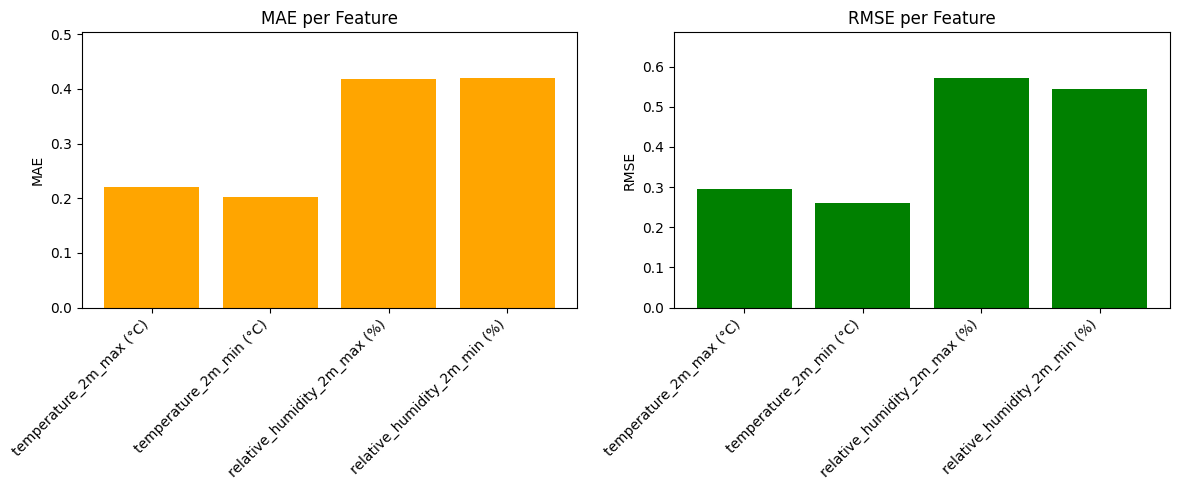

In [20]:
def show_weather_predictions(
    model, 
    y_true, y_pred, 
    y_temp_humidity_true=None, y_temp_humidity_pred=None, 
    num_samples=5
):
    """Display actual vs predicted weather conditions and optionally temperature/humidity metrics."""
    import numpy as np
    import matplotlib.pyplot as plt

    print("🌤️  WEATHER CONDITION PREDICTIONS")
    print("=" * 60)

    sample_size = min(num_samples, len(y_true))

    for i in range(sample_size):
        # Convert numeric predictions back to weather condition names
        actual_conditions = model.label_encoder.inverse_transform(y_true[i])
        pred_conditions = model.label_encoder.inverse_transform(y_pred[i])

        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 40)

        # Create a nice table format
        print(f"{'Day':>5} | {'Actual Weather':^20} | {'Predicted Weather':^20} | {'Match':^6}")
        print("-" * 65)

        matches = 0
        for day in range(model.forecast_horizon):
            actual = actual_conditions[day]
            predicted = pred_conditions[day]
            match = "✅" if actual == predicted else "❌"
            if actual == predicted:
                matches += 1

            print(f"{day+1:>5} | {actual:^20} | {predicted:^20} | {match:^6}")

        accuracy = matches / model.forecast_horizon
        print("-" * 65)
        print(f"Sequence Accuracy: {matches}/{model.forecast_horizon} ({accuracy:.1%})")

    # Overall statistics for weather
    print(f"\n📊 OVERALL WEATHER STATISTICS:")
    print("=" * 40)

    total_predictions = y_true.size
    correct_predictions = np.sum(y_true == y_pred)
    overall_accuracy = correct_predictions / total_predictions

    print(f"Total Predictions: {total_predictions:,}")
    print(f"Correct Predictions: {correct_predictions:,}")
    print(f"Overall Accuracy: {overall_accuracy:.1%}")

    # Per-day accuracy
    print(f"\n📈 DAILY ACCURACY BREAKDOWN:")
    print("-" * 30)
    for day in range(model.forecast_horizon):
        day_correct = np.sum(y_true[:, day] == y_pred[:, day])
        day_total = len(y_true)
        day_accuracy = day_correct / day_total
        print(f"Day {day+1}: {day_accuracy:.1%} ({day_correct}/{day_total})")

    # Temperature and Humidity Regression Section (if data available)
    if y_temp_humidity_true is not None and y_temp_humidity_pred is not None:
        from sklearn.metrics import mean_absolute_error, mean_squared_error
        import numpy as np
        print(f"\n🌡️ TEMPERATURE & HUMIDITY REGRESSION RESULTS")
        print("=" * 40)

        num_features = y_temp_humidity_true.shape[2]
        feature_names = model.available_temp_humidity_cols if model.available_temp_humidity_cols else [f"Feature {i}" for i in range(num_features)]

        for f in range(num_features):
            mae = mean_absolute_error(y_temp_humidity_true[:, :, f].flatten(), y_temp_humidity_pred[:, :, f].flatten())
            rmse = np.sqrt(mean_squared_error(y_temp_humidity_true[:, :, f].flatten(), y_temp_humidity_pred[:, :, f].flatten()))
            print(f"  {feature_names[f]}: MAE = {mae:.3f}, RMSE = {rmse:.3f}")

        # Optional: plot errors per feature
        maes = []
        rmses = []
        for f in range(num_features):
            maes.append(mean_absolute_error(y_temp_humidity_true[:, :, f].flatten(), y_temp_humidity_pred[:, :, f].flatten()))
            rmses.append(np.sqrt(mean_squared_error(y_temp_humidity_true[:, :, f].flatten(), y_temp_humidity_pred[:, :, f].flatten())))

        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        ax[0].bar(feature_names, maes, color='orange')
        ax[0].set_title("MAE per Feature")
        ax[0].set_ylabel("MAE")
        ax[0].set_ylim(0, max(maes) * 1.2)
        ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right', fontsize=10)

        ax[1].bar(feature_names, rmses, color='green')
        ax[1].set_title("RMSE per Feature")
        ax[1].set_ylabel("RMSE")
        ax[1].set_ylim(0, max(rmses) * 1.2)
        ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right', fontsize=10)

        plt.tight_layout()
        plt.show()

show_weather_predictions(
    model, 
    y_weather_true, y_weather_pred, 
    y_temp_humidity_true=y_temp_humidity_true, 
    y_temp_humidity_pred=y_temp_humidity_pred, 
    num_samples=3
)


In [ ]:
def save_lstm_model(model, model_name="LSTM Model All Together", save_dir="saved_models"):
    """
    Save the complete LSTM model including weights, architecture, and preprocessing components
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)
    
    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)
    
    try:
        # Save Keras model
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print(f"✅ Keras model saved: keras_model.keras")
        
        # Save label encoder
        encoder_path = f"{model_folder}/label_encoder.pkl"
        with open(encoder_path, 'wb') as f:
            pickle.dump(model.label_encoder, f)
        print(f"✅ Label encoder saved: label_encoder.pkl")
        
        # Save main scaler if exists
        if hasattr(model, 'scaler') and model.scaler is not None:
            scaler_path = f"{model_folder}/scaler.pkl"
            joblib.dump(model.scaler, scaler_path)
            print(f"✅ Scaler saved: scaler.pkl")
        
        # Save temp/humidity scaler separately if it exists and is different
        if hasattr(model, 'temp_humidity_scaler') and model.temp_humidity_scaler is not None:
            th_scaler_path = f"{model_folder}/temp_humidity_scaler.pkl"
            joblib.dump(model.temp_humidity_scaler, th_scaler_path)
            print(f"✅ Temp/Humidity scaler saved: temp_humidity_scaler.pkl")
        
        # Save model config including temp/humidity feature names if available
        model_config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'feature_columns': getattr(model, 'feature_columns', []),
            'target_column': getattr(model, 'target_column', 'weather_condition'),
            'num_classes': len(model.label_encoder.classes_),
            'class_names': model.label_encoder.classes_.tolist(),
            'minority_classes': getattr(model, 'minority_classes', []),
            'available_temp_humidity_cols': getattr(model, 'available_temp_humidity_cols', []),
            'timestamp': timestamp,
            'model_type': 'SlidingWindowWeatherModel',
            'framework': 'TensorFlow/Keras'
        }
        config_path = f"{model_folder}/model_config.json"
        with open(config_path, 'w') as f:
            json.dump(model_config, f, indent=4)
        print(f"✅ Model configuration saved: model_config.json")
        
        # Save full model object excluding keras model
        full_model_path = f"{model_folder}/full_model.pkl"
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)
        with open(full_model_path, 'wb') as f:
            pickle.dump(model_copy, f)
        print(f"✅ Full model object saved: full_model.pkl")
        
        # Save README
        readme_content = f"""# {model_name}

Saved on: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

## Model Details:
- Model Type: LSTM Weather Forecasting Model
- Sequence Length: {model.sequence_length} days
- Forecast Horizon: {model.forecast_horizon} days
- Number of Classes: {len(model.label_encoder.classes_)}
- Weather Conditions: {', '.join(model.label_encoder.classes_)}
- Temp/Humidity Features: {', '.join(getattr(model, 'available_temp_humidity_cols', []))}

## Files:
- keras_model.keras: TensorFlow/Keras model architecture and weights
- label_encoder.pkl: Label encoder for weather conditions
- scaler.pkl: Feature scaler (if used)
- temp_humidity_scaler.pkl: Scaler for temperature/humidity features (if used)
- model_config.json: Model configuration and metadata
- full_model.pkl: Complete model object (without Keras model)
- README.md: This file

## Loading Instructions:
python
# Load using the load_lstm_model function
model = load_lstm_model('{model_folder}')

# Or load components manually:
from tensorflow.keras.models import load_model
import pickle

# Load Keras model
keras_model = load_model('{model_folder}/keras_model.keras')

# Load label encoder
with open('{model_folder}/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# Load scalers if needed
"""
        readme_path = f"{model_folder}/README.md"
        with open(readme_path, 'w', encoding='utf-8') as f:
            f.write(readme_content)
        print(f"✅ README file created: README.md")
        
        print(f"\n🎉 '{model_name}' successfully saved!")
        print(f"📁 Location: {model_folder}")
        print(f"📊 Model info: {len(model.label_encoder.classes_)} weather classes, {model.sequence_length}→{model.forecast_horizon} day forecast")
        
        return model_folder
        
    except Exception as e:
        print(f"❌ Error saving model: {str(e)}")
        return None


def load_lstm_model(model_folder):
    """
    Load a saved LSTM model including temp/humidity scaler if available
    """
    try:
        print(f"📂 Loading model from: {model_folder}")
        
        config_path = f"{model_folder}/model_config.json"
        with open(config_path, 'r') as f:
            config = json.load(f)
        
        print(f"🔄 Loading '{config['model_name']}'...")
        
        from tensorflow.keras.models import load_model
        keras_model = load_model(f"{model_folder}/keras_model.keras")
        
        with open(f"{model_folder}/label_encoder.pkl", 'rb') as f:
            label_encoder = pickle.load(f)
        
        scaler = None
        scaler_path = f"{model_folder}/scaler.pkl"
        if os.path.exists(scaler_path):
            scaler = joblib.load(scaler_path)
        
        temp_humidity_scaler = None
        th_scaler_path = f"{model_folder}/temp_humidity_scaler.pkl"
        if os.path.exists(th_scaler_path):
            temp_humidity_scaler = joblib.load(th_scaler_path)
        
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)
        
        print("⚠️  Note: You'll need to recreate your SlidingWindowWeatherModel class and assign components.")
        
        return {
            'keras_model': keras_model,
            'label_encoder': label_encoder,
            'scaler': scaler,
            'temp_humidity_scaler': temp_humidity_scaler,
            'config': config,
            'model_dict': model_dict
        }
    
    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")
        return None

# Usage:
model_folder = save_lstm_model(model, "LSTM Model TEMP HUMIDITY AND WEATHER")
# loaded_components = load_lstm_model(model_folder)


💾 Saving 'LSTM Model 4' to: saved_models/LSTM_Model_4_20250623_162944
✅ Keras model saved: keras_model.keras
✅ Label encoder saved: label_encoder.pkl
✅ Model configuration saved: model_config.json
✅ Full model object saved: full_model.pkl
✅ README file created: README.md

🎉 'LSTM Model 4' successfully saved!
📁 Location: saved_models/LSTM_Model_4_20250623_162944
📊 Model info: 9 weather classes, 10→3 day forecast


**Option 4 : Predicting temp and humidity**

In [3]:
class TemperatureHumidityLSTM:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        """
        Dedicated LSTM model for temperature and humidity prediction
        """
        self.df = df.copy()
        self.sequence_length = sequence_length
        self.forecast_horizon = forecast_horizon
        self.scaler_features = None
        self.scaler_targets = None
        self.model = None
        
        # Temperature and humidity target columns
        self.target_cols = [
            'temperature_2m_max (°C)', 
            'temperature_2m_min (°C)', 
            'relative_humidity_2m_max (%)', 
            'relative_humidity_2m_min (%)'
        ]
        
    def preprocess_data(self):
        """Preprocess data specifically for temperature and humidity prediction"""
        print("🧹 Preprocessing data for temperature and humidity prediction...")
        df = self.df.copy()
        
        # Check which target columns are available
        available_targets = [col for col in self.target_cols if col in df.columns]
        if not available_targets:
            raise ValueError(f"None of the target columns {self.target_cols} found in the dataframe")
        
        self.available_targets = available_targets
        print(f"Available target columns: {available_targets}")
        
        # Handle missing values for targets
        for col in available_targets:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with any missing target values
        df = df.dropna(subset=available_targets)
        
        # Define feature columns (exclude date, weather_condition, and target columns)
        exclude_cols = ['date', 'weather_condition'] + available_targets
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        
        # Handle missing values for features
        numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Scale features
        self.scaler_features = StandardScaler()
        df[feature_cols] = self.scaler_features.fit_transform(df[feature_cols])
        
        # Scale targets
        self.scaler_targets = StandardScaler()
        df[available_targets] = self.scaler_targets.fit_transform(df[available_targets])
        
        # Store processed data
        self.df_processed = df
        self.feature_cols = feature_cols
        
        print(f"Feature columns ({len(feature_cols)}): {feature_cols[:5]}..." if len(feature_cols) > 5 else f"Feature columns: {feature_cols}")
        print(f"Target columns: {available_targets}")
        print(f"Data shape after preprocessing: {df.shape}")
        
        return df
    
    def create_sequences(self):
        """Create sequences for temperature and humidity prediction"""
        print(f"🪟 Creating sequences for temperature and humidity prediction...")
        
        X, y = [], []
        data = self.df_processed
        features = data[self.feature_cols].values
        targets = data[self.available_targets].values
        
        # Create sequences with sliding window
        for i in range(len(data) - self.sequence_length - self.forecast_horizon + 1):
            # Input sequence
            X_seq = features[i:i + self.sequence_length]
            
            # Target sequence (next forecast_horizon days)
            y_seq = targets[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            X.append(X_seq)
            y.append(y_seq)
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Created sequences: X={X.shape}, y={y.shape}")
        print(f"Input sequence length: {self.sequence_length}")
        print(f"Forecast horizon: {self.forecast_horizon}")
        print(f"Number of features: {X.shape[2]}")
        print(f"Number of target variables: {y.shape[2]}")
        
        return X, y
    
    def build_model(self, input_shape, output_shape):
        """Build LSTM model for temperature and humidity prediction"""
        model = Sequential([
            # First LSTM layer
            LSTM(128, return_sequences=True, input_shape=input_shape,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Second LSTM layer
            LSTM(64, return_sequences=True,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Third LSTM layer
            LSTM(32, return_sequences=False,
                 kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dropout(0.3),
            
            # Dense layers for multi-step prediction
            Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            
            Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
            Dropout(0.2),
            
            # Output layer - predict all forecast steps and variables at once
            Dense(output_shape[0] * output_shape[1], activation='linear'),
            
            # Reshape to (forecast_horizon, num_target_variables)
            tf.keras.layers.Reshape(output_shape)
        ])
        
        return model
    
    def train_model(self, validation_split=0.2, epochs=150, batch_size=32):
        """Train the temperature and humidity LSTM model"""
        print("\n" + "="*70)
        print("TRAINING TEMPERATURE & HUMIDITY LSTM MODEL")
        print("="*70)
        
        # Create sequences
        X, y = self.create_sequences()
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, shuffle=True
        )
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build model
        input_shape = (self.sequence_length, X.shape[2])
        output_shape = (self.forecast_horizon, len(self.available_targets))
        
        self.model = self.build_model(input_shape, output_shape)
        
        # Compile model
        self.model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        print(f"\nModel architecture:")
        self.model.summary()
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print(f"\nTraining model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print(f"\nEvaluating model...")
        y_pred = self.model.predict(X_test, verbose=0)
        
        return self.evaluate_model(y_test, y_pred, history)
    
    def evaluate_model(self, y_true, y_pred, history):
        """Evaluate the temperature and humidity model"""
        print("\n" + "="*70)
        print("TEMPERATURE & HUMIDITY LSTM RESULTS")
        print("="*70)
        
        # Inverse transform predictions and true values to original scale
        y_true_original = np.zeros_like(y_true)
        y_pred_original = np.zeros_like(y_pred)
        
        for day in range(self.forecast_horizon):
            y_true_original[:, day, :] = self.scaler_targets.inverse_transform(y_true[:, day, :])
            y_pred_original[:, day, :] = self.scaler_targets.inverse_transform(y_pred[:, day, :])
        
        # Calculate metrics for each target variable and forecast day
        results = {}
        
        for i, target_name in enumerate(self.available_targets):
            print(f"\n🌡️ {target_name}:")
            print("-" * 50)
            
            target_results = {
                'mae': [],
                'rmse': [],
                'r2': [],
                'mape': []
            }
            
            for day in range(self.forecast_horizon):
                y_true_day = y_true_original[:, day, i]
                y_pred_day = y_pred_original[:, day, i]
                
                mae = mean_absolute_error(y_true_day, y_pred_day)
                rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
                r2 = r2_score(y_true_day, y_pred_day)
                
                # Calculate MAPE (Mean Absolute Percentage Error)
                mape = np.mean(np.abs((y_true_day - y_pred_day) / (y_true_day + 1e-8))) * 100
                
                target_results['mae'].append(mae)
                target_results['rmse'].append(rmse)
                target_results['r2'].append(r2)
                target_results['mape'].append(mape)
                
                print(f"  Day {day+1}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}, MAPE={mape:.2f}%")
            
            # Calculate averages
            avg_mae = np.mean(target_results['mae'])
            avg_rmse = np.mean(target_results['rmse'])
            avg_r2 = np.mean(target_results['r2'])
            avg_mape = np.mean(target_results['mape'])
            
            target_results['avg_mae'] = avg_mae
            target_results['avg_rmse'] = avg_rmse
            target_results['avg_r2'] = avg_r2
            target_results['avg_mape'] = avg_mape
            
            print(f"  Average: MAE={avg_mae:.3f}, RMSE={avg_rmse:.3f}, R²={avg_r2:.3f}, MAPE={avg_mape:.2f}%")
            
            results[target_name] = target_results
        
        # Overall performance summary
        print(f"\n📊 OVERALL PERFORMANCE SUMMARY:")
        print("="*50)
        
        all_maes = [results[target]['avg_mae'] for target in self.available_targets]
        all_rmses = [results[target]['avg_rmse'] for target in self.available_targets]
        all_r2s = [results[target]['avg_r2'] for target in self.available_targets]
        all_mapes = [results[target]['avg_mape'] for target in self.available_targets]
        
        print(f"Overall Average MAE: {np.mean(all_maes):.3f}")
        print(f"Overall Average RMSE: {np.mean(all_rmses):.3f}")
        print(f"Overall Average R²: {np.mean(all_r2s):.3f}")
        print(f"Overall Average MAPE: {np.mean(all_mapes):.2f}%")
        
        # Best and worst performing variables
        best_target = min(results.keys(), key=lambda x: results[x]['avg_mae'])
        worst_target = max(results.keys(), key=lambda x: results[x]['avg_mae'])
        
        print(f"\n🏆 Best performing variable: {best_target} (MAE: {results[best_target]['avg_mae']:.3f})")
        print(f"⚠️  Worst performing variable: {worst_target} (MAE: {results[worst_target]['avg_mae']:.3f})")
        
        return results, history, y_true_original, y_pred_original
    
    def predict_future(self, recent_data, days_ahead=None):
        """Predict temperature and humidity for future days"""
        if days_ahead is None:
            days_ahead = self.forecast_horizon
        
        if isinstance(recent_data, pd.DataFrame):
            # Ensure recent_data has the same preprocessing
            recent_scaled = self.scaler_features.transform(recent_data[self.feature_cols])
        else:
            recent_scaled = recent_data
        
        # Use the last sequence_length days as input
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        
        # Make prediction
        prediction_scaled = self.model.predict(input_seq, verbose=0)
        
        # Inverse transform to original scale
        prediction_original = np.zeros_like(prediction_scaled)
        for day in range(self.forecast_horizon):
            prediction_original[0, day, :] = self.scaler_targets.inverse_transform(
                prediction_scaled[0, day, :].reshape(1, -1)
            )
        
        # Create results dictionary
        results = {}
        for i, target_name in enumerate(self.available_targets):
            results[target_name] = prediction_original[0, :days_ahead, i]
        
        return results
    
    def plot_training_history(self, history):
        """Plot training history"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss
        ax1.plot(history.history['loss'], label='Training Loss')
        ax1.plot(history.history['val_loss'], label='Validation Loss')
        ax1.set_title('Model Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        
        # MAE
        ax2.plot(history.history['mae'], label='Training MAE')
        ax2.plot(history.history['val_mae'], label='Validation MAE')
        ax2.set_title('Model MAE')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

🌡️ DEDICATED TEMPERATURE & HUMIDITY LSTM FORECASTING
🧹 Preprocessing data for temperature and humidity prediction...
Available target columns: ['temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'relative_humidity_2m_max (%)', 'relative_humidity_2m_min (%)']
Feature columns (144): ['year', 'month', 'day', 'dayofweek', 'is_weekend']...
Target columns: ['temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'relative_humidity_2m_max (%)', 'relative_humidity_2m_min (%)']
Data shape after preprocessing: (9252, 150)

TRAINING TEMPERATURE & HUMIDITY LSTM MODEL
🪟 Creating sequences for temperature and humidity prediction...
Created sequences: X=(9240, 10, 144), y=(9240, 3, 4)
Input sequence length: 10
Forecast horizon: 3
Number of features: 144
Number of target variables: 4
Training samples: 7392, Test samples: 1848

Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 128)        │       139,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 4)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,340 (809.92 KB)

 Trainable params: 206,764 (807.67 KB)

 Non-trainable params: 576 (2.25 KB)


Training model...
Epoch 1/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - loss: 2.4867 - mae: 1.0961 - val_loss: 1.3245 - val_mae: 0.7129 - learning_rate: 0.0010
Epoch 2/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.4304 - mae: 0.7464 - val_loss: 1.1047 - val_mae: 0.6075 - learning_rate: 0.0010
Epoch 3/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 1.1969 - mae: 0.6681 - val_loss: 0.9923 - val_mae: 0.5712 - learning_rate: 0.0010
Epoch 4/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 1.0837 - mae: 0.6371 - val_loss: 0.8997 - val_mae: 0.5478 - learning_rate: 0.0010
Epoch 5/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.9795 - mae: 0.6121 - val_loss: 0.8322 - val_mae: 0.5323 - learning_rate: 0.0010
Epoch 6/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.9072 - mae: 0.5969 - val_loss: 0.7804 - val_mae: 0.5252 - learning_rate: 0.0010
Epoch 7/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.8442 - mae: 0.5849 - val_loss: 0.7403 - val_mae: 0.5223 - learning

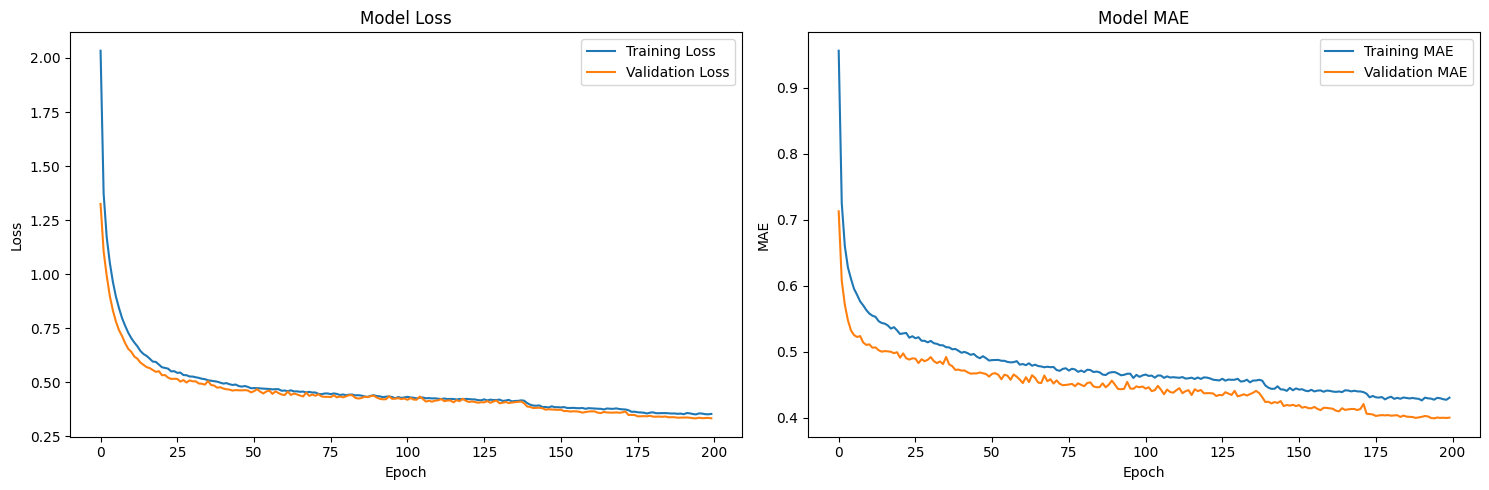

In [4]:
def run_temperature_humidity_forecasting(df):
    """Run dedicated temperature and humidity forecasting"""
    print("🌡️ DEDICATED TEMPERATURE & HUMIDITY LSTM FORECASTING")
    print("=" * 70)
    
    # Initialize model
    model = TemperatureHumidityLSTM(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data()
    
    # Train model
    results, history, y_true, y_pred = model.train_model(
        validation_split=0.2, 
        epochs=200, 
        batch_size=64
    )
    
    # Plot training history
    model.plot_training_history(history)
    
    return model, results, history, y_true, y_pred

# Usage example:
model, results, history, y_true, y_pred = run_temperature_humidity_forecasting(df)


🔮 Making 3-day temperature and humidity forecast...
--------------------------------------------------
📅 3-Day Temperature & Humidity Forecast:
  Thursday   (2025-05-01):
     🌡️ temperature_2m_max (°C): 36.94
     🌡️ temperature_2m_min (°C): 25.30
     🌡️ relative_humidity_2m_max (%): 68.60
     🌡️ relative_humidity_2m_min (%): 25.11
  Friday     (2025-05-02):
     🌡️ temperature_2m_max (°C): 35.94
     🌡️ temperature_2m_min (°C): 25.08
     🌡️ relative_humidity_2m_max (%): 72.74
     🌡️ relative_humidity_2m_min (%): 29.63
  Saturday   (2025-05-03):
     🌡️ temperature_2m_max (°C): 34.77
     🌡️ temperature_2m_min (°C): 24.69
     🌡️ relative_humidity_2m_max (%): 79.35
     🌡️ relative_humidity_2m_min (%): 34.44


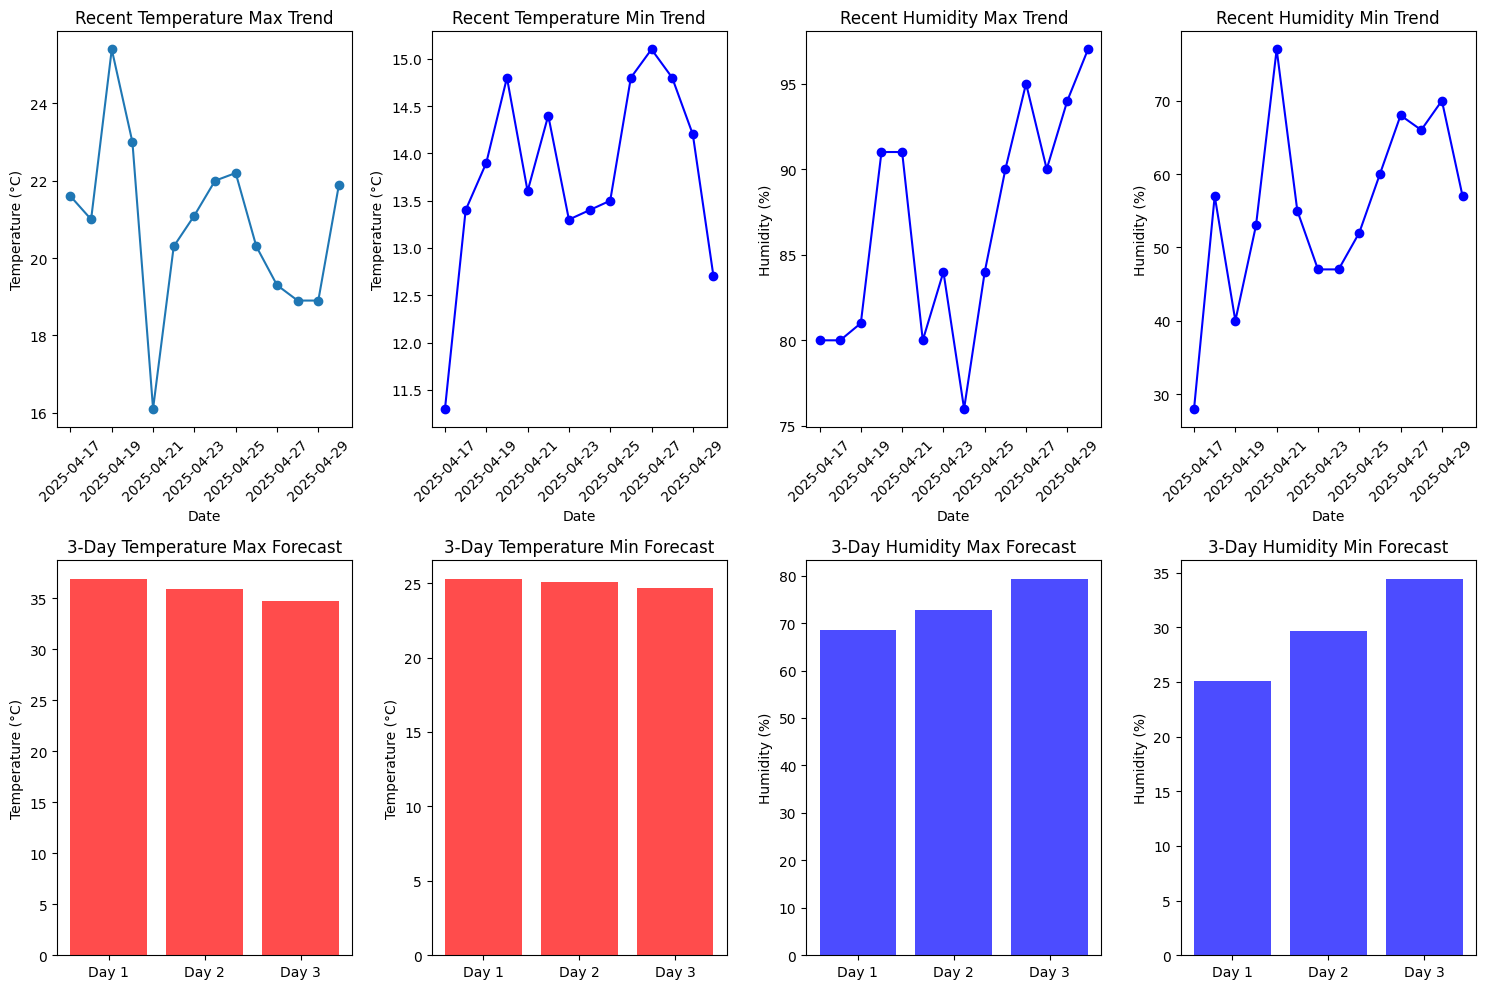

In [6]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations for temperature/humidity only"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    import pandas as pd
    import numpy as np
    
    print("\n🔮 Making 3-day temperature and humidity forecast...")
    print("-" * 50)
    
    # Get only the features used during training
    feature_cols = model.feature_cols

    # Pull only the last `sequence_length` rows
    recent_data = df[feature_cols].tail(model.sequence_length).copy()

    # Ensure numeric and same dtype
    recent_data = recent_data.apply(pd.to_numeric, errors='coerce').dropna()

    # If any rows dropped, re-pad from the top
    if len(recent_data) < model.sequence_length:
        padding_needed = model.sequence_length - len(recent_data)
        padding = np.zeros((padding_needed, len(feature_cols)))
        recent_data = np.vstack([padding, recent_data.values])
    else:
        recent_data = recent_data.values

    # Final shape must be (1, sequence_length, num_features)
    recent_data = recent_data.reshape(1, model.sequence_length, len(feature_cols)).astype(np.float32)

    try:
        # Get temperature/humidity predictions
        temp_humidity_results = model.predict_future(recent_data)
        
        # Get next 3 days
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        print("📅 3-Day Temperature & Humidity Forecast:")
        for i, (day, date) in enumerate(days_and_dates):
            print(f"  {day:10} ({date}):")
            for target_name in model.available_targets:
                value = temp_humidity_results[target_name][i]
                print(f"     🌡️ {target_name}: {value:.2f}")
        
        # Visualization
        fig, axes = plt.subplots(2, 4, figsize=(15, 10))
        
        # Plot recent temperature trends
        if 'temperature_2m_max (°C)' in df.columns:
            recent_temp = df[['date', 'temperature_2m_max (°C)']].tail(14)
            recent_temp['date'] = pd.to_datetime(recent_temp['date'])
            axes[0, 0].plot(recent_temp['date'], recent_temp['temperature_2m_max (°C)'], 'o-')
            axes[0, 0].set_title('Recent Temperature Max Trend')
            axes[0, 0].set_xlabel('Date')
            axes[0, 0].set_ylabel('Temperature (°C)')
            axes[0, 0].tick_params(axis='x', rotation=45)
        
        # Plot recent temp min trends
        if 'temperature_2m_min (°C)' in df.columns:
            recent_temp = df[['date', 'temperature_2m_min (°C)']].tail(14)
            recent_temp['date'] = pd.to_datetime(recent_temp['date'])
            axes[0, 1].plot(recent_temp['date'], recent_temp['temperature_2m_min (°C)'], 'o-', color='blue')
            axes[0, 1].set_title('Recent Temperature Min Trend')
            axes[0, 1].set_xlabel('Date')
            axes[0, 1].set_ylabel('Temperature (°C)')
            axes[0, 1].tick_params(axis='x', rotation=45)

        # Plot recent humidity ùax trends
        if 'relative_humidity_2m_max (%)' in df.columns:
            recent_humidity = df[['date', 'relative_humidity_2m_max (%)']].tail(14)
            recent_humidity['date'] = pd.to_datetime(recent_humidity['date'])
            axes[0, 2].plot(recent_humidity['date'], recent_humidity['relative_humidity_2m_max (%)'], 'o-', color='blue')
            axes[0, 2].set_title('Recent Humidity Max Trend')
            axes[0, 2].set_xlabel('Date')
            axes[0, 2].set_ylabel('Humidity (%)')
            axes[0, 2].tick_params(axis='x', rotation=45)

        # Plot recent humidity min trends
        if 'relative_humidity_2m_min (%)' in df.columns:
            recent_humidity = df[['date', 'relative_humidity_2m_min (%)']].tail(14)
            recent_humidity['date'] = pd.to_datetime(recent_humidity['date'])
            axes[0, 3].plot(recent_humidity['date'], recent_humidity['relative_humidity_2m_min (%)'], 'o-', color='blue')
            axes[0, 3].set_title('Recent Humidity Min Trend')
            axes[0, 3].set_xlabel('Date')
            axes[0, 3].set_ylabel('Humidity (%)')
            axes[0, 3].tick_params(axis='x', rotation=45)

        # Plot forecast temperature
        forecast_days = [f"Day {i+1}" for i in range(3)]
        if 'temperature_2m_max (°C)' in temp_humidity_results:
            temp_forecast = temp_humidity_results['temperature_2m_max (°C)']
            axes[1, 0].bar(forecast_days, temp_forecast, color='red', alpha=0.7)
            axes[1, 0].set_title('3-Day Temperature Max Forecast')
            axes[1, 0].set_ylabel('Temperature (°C)')

        if 'temperature_2m_min (°C)' in temp_humidity_results:
            temp_forecast = temp_humidity_results['temperature_2m_min (°C)']
            axes[1, 1].bar(forecast_days, temp_forecast, color='red', alpha=0.7)
            axes[1, 1].set_title('3-Day Temperature Min Forecast')
            axes[1, 1].set_ylabel('Temperature (°C)')
        
        # Plot forecast humidity
        if 'relative_humidity_2m_max (%)' in temp_humidity_results:
            humidity_forecast = temp_humidity_results['relative_humidity_2m_max (%)']
            axes[1, 2].bar(forecast_days, humidity_forecast, color='blue', alpha=0.7)
            axes[1, 2].set_title('3-Day Humidity Max Forecast')
            axes[1, 2].set_ylabel('Humidity (%)')

        if 'relative_humidity_2m_min (%)' in temp_humidity_results:
            humidity_forecast = temp_humidity_results['relative_humidity_2m_min (%)']
            axes[1, 3].bar(forecast_days, humidity_forecast, color='blue', alpha=0.7)
            axes[1, 3].set_title('3-Day Humidity Min Forecast')
            axes[1, 3].set_ylabel('Humidity (%)')
        
        plt.tight_layout()
        plt.show()
        
        return temp_humidity_results
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None


# Usage example:

predictions = make_predictions_and_visualize(model, df)

🌡️  TEMPERATURE & HUMIDITY PREDICTIONS

📅 Test Sequence 1:
------------------------------------------------------------

🌡️  temperature_2m_max (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      35.00 |      35.43 |       0.43 |       1.2%
    2 |      35.50 |      35.96 |       0.46 |       1.3%
    3 |      37.80 |      35.94 |       1.86 |       4.9%
------------------------------------------------------------
Sequence MAE: 0.916

🌡️  temperature_2m_min (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      21.90 |      23.50 |       1.60 |       7.3%
    2 |      23.90 |      23.85 |       0.05 |       0.2%
    3 |      24.90 |      24.19 |       0.71 |       2.9%
------------------------------------------------------------
Sequence M

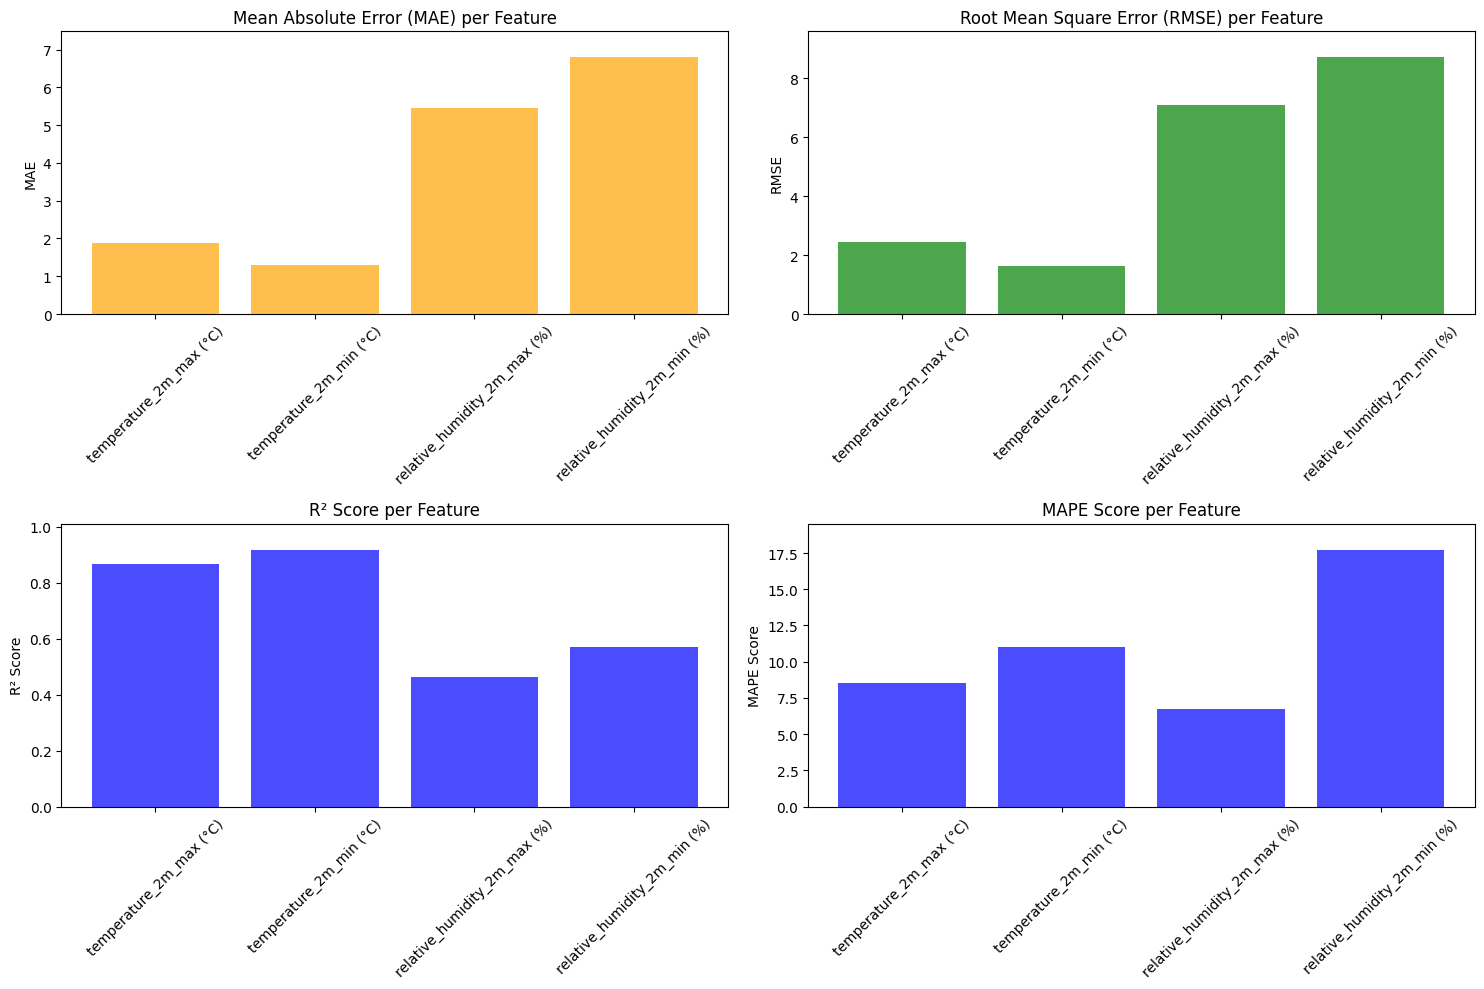


🏆 PERFORMANCE SUMMARY:
Best performing feature: temperature_2m_min (°C) (MAE: 1.290)
Worst performing feature: relative_humidity_2m_min (%) (MAE: 6.802)
Overall average MAE: 3.856
Overall average RMSE: 4.978
Overall average R²: 0.704


In [12]:
def show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=5
):
    """Display temperature and humidity regression predictions only."""
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print("🌡️  TEMPERATURE & HUMIDITY PREDICTIONS")
    print("=" * 60)

    sample_size = min(num_samples, len(y_true))

    # Get feature names from the model
    feature_names = model.available_targets if hasattr(model, 'available_targets') else [f"Feature {i}" for i in range(y_true.shape[2])]

    # Display sample predictions
    for i in range(sample_size):
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 60)

        # Create a nice table format for each feature
        for f, feature_name in enumerate(feature_names):
            print(f"\n🌡️  {feature_name}:")
            print("-" * 40)
            print(f"{'Day':>5} | {'Actual':>10} | {'Predicted':>10} | {'Error':>10} | {'% Error':>10}")
            print("-" * 60)

            mae_sequence = 0
            for day in range(model.forecast_horizon):
                actual = y_true[i, day, f]
                predicted = y_pred[i, day, f]
                error = abs(actual - predicted)
                percent_error = (error / (abs(actual) + 1e-8)) * 100
                mae_sequence += error

                print(f"{day+1:>5} | {actual:>10.2f} | {predicted:>10.2f} | {error:>10.2f} | {percent_error:>9.1f}%")

            mae_sequence /= model.forecast_horizon
            print("-" * 60)
            print(f"Sequence MAE: {mae_sequence:.3f}")

    # Overall statistics for temperature and humidity
    print(f"\n📊 OVERALL REGRESSION STATISTICS:")
    print("=" * 50)

    num_features = y_true.shape[2]

    for f, feature_name in enumerate(feature_names):
        print(f"\n🌡️  {feature_name}:")
        print("-" * 30)
        
        # Calculate metrics for this feature
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        mae = mean_absolute_error(y_true_flat, y_pred_flat)
        rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
        r2 = r2_score(y_true_flat, y_pred_flat)
        mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100
        
        print(f"  MAE:  {mae:.3f}")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  R²:   {r2:.3f}")
        print(f"  MAPE: {mape:.2f}%")
        
        # Per-day accuracy for this feature
        print(f"\n  📈 Daily Performance:")
        for day in range(model.forecast_horizon):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae = mean_absolute_error(day_true, day_pred)
            day_rmse = np.sqrt(mean_squared_error(day_true, day_pred))
            day_r2 = r2_score(day_true, day_pred)
            print(f"    Day {day+1}: MAE={day_mae:.3f}, RMSE={day_rmse:.3f}, R²={day_r2:.3f}")

    # Create visualization
    print(f"\n📈 CREATING PERFORMANCE VISUALIZATION...")
    
    # Calculate metrics for plotting
    maes = []
    rmses = []
    r2s = []
    mape = []
    
    for f in range(num_features):
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        maes.append(mean_absolute_error(y_true_flat, y_pred_flat))
        rmses.append(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))
        r2s.append(r2_score(y_true_flat, y_pred_flat))
        mape.append(np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100)
        

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # MAE plot
    axes[0, 0].bar(feature_names, maes, color='orange', alpha=0.7)
    axes[0, 0].set_title("Mean Absolute Error (MAE) per Feature")
    axes[0, 0].set_ylabel("MAE")
    axes[0, 0].set_ylim(0, max(maes) * 1.1)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # RMSE plot
    axes[0, 1].bar(feature_names, rmses, color='green', alpha=0.7)
    axes[0, 1].set_title("Root Mean Square Error (RMSE) per Feature")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].set_ylim(0, max(rmses) * 1.1)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # R² plot
    axes[1, 0].bar(feature_names, r2s, color='blue', alpha=0.7)
    axes[1, 0].set_title("R² Score per Feature")
    axes[1, 0].set_ylabel("R² Score")
    axes[1, 0].set_ylim(0, max(1.0, max(r2s) * 1.1))
    axes[1, 0].tick_params(axis='x', rotation=45)

    # Mape plot
    axes[1, 1].bar(feature_names, mape, color='blue', alpha=0.7)
    axes[1, 1].set_title("MAPE Score per Feature")
    axes[1, 1].set_ylabel("MAPE Score")
    axes[1, 1].set_ylim(0, max(mape) * 1.1)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n🏆 PERFORMANCE SUMMARY:")
    print("=" * 30)
    print(f"Best performing feature: {feature_names[np.argmin(maes)]} (MAE: {min(maes):.3f})")
    print(f"Worst performing feature: {feature_names[np.argmax(maes)]} (MAE: {max(maes):.3f})")
    print(f"Overall average MAE: {np.mean(maes):.3f}")
    print(f"Overall average RMSE: {np.mean(rmses):.3f}")
    print(f"Overall average R²: {np.mean(r2s):.3f}")


# Usage example - replace your original function call with this:
show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=3
)

In [13]:
def save_lstm_model(model, model_name="TemperatureHumidityLSTM", save_dir="saved_models"):
    import os
    import json
    import pickle
    from datetime import datetime
    import joblib

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)

    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)

    try:
        # 1. Save the Keras model
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print("✅ Keras model saved.")

        # 2. Save scalers
        joblib.dump(model.scaler_features, f"{model_folder}/scaler_features.pkl")
        joblib.dump(model.scaler_targets, f"{model_folder}/scaler_targets.pkl")
        print("✅ Scalers saved.")

        # 3. Save config
        config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'available_targets': model.available_targets,
            'feature_columns': model.feature_cols,
            'timestamp': timestamp,
            'model_type': 'TemperatureHumidityLSTM',
            'framework': 'TensorFlow/Keras'
        }
        with open(f"{model_folder}/model_config.json", 'w') as f:
            json.dump(config, f, indent=4)
        print("✅ Model configuration saved.")

        # 4. Save model object (without keras model to avoid issues)
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)
        with open(f"{model_folder}/full_model.pkl", 'wb') as f:
            pickle.dump(model_copy, f)
        print("✅ Full model object saved.")

        return model_folder

    except Exception as e:
        print(f"❌ Error saving model: {e}")
        return None



def load_lstm_model(model_folder):
    import os
    import json
    import pickle
    import joblib
    from tensorflow.keras.models import load_model

    try:
        print(f"📂 Loading model from: {model_folder}")

        # Load keras model
        keras_model = load_model(f"{model_folder}/keras_model.keras")

        # Load scalers
        scaler_features = joblib.load(f"{model_folder}/scaler_features.pkl")
        scaler_targets = joblib.load(f"{model_folder}/scaler_targets.pkl")

        # Load config
        with open(f"{model_folder}/model_config.json", 'r') as f:
            config = json.load(f)

        # Load full model dict
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)

        # Create empty model object
        model = TemperatureHumidityLSTM(pd.DataFrame(), config['sequence_length'], config['forecast_horizon'])
        model.model = keras_model
        model.scaler_features = scaler_features
        model.scaler_targets = scaler_targets

        # Restore other attributes
        for key, value in model_dict.items():
            setattr(model, key, value)

        print(f"✅ Model '{config['model_name']}' successfully loaded!")
        return model

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None


model_folder = save_lstm_model(model, model_name="TemperatureHumidityLSTM_Model1")

💾 Saving 'TemperatureHumidityLSTM_Model1' to: saved_models/TemperatureHumidityLSTM_Model1_20250706_153549
✅ Keras model saved.
✅ Scalers saved.
✅ Model configuration saved.
✅ Full model object saved.


**Searching for the best parameters**

In [14]:
class TemperatureHumidityLSTM:
    def __init__(self, df, sequence_length=10, forecast_horizon=3, lstm_units=(128, 64, 32),
                 dense_units=(64, 32), dropout_rate=0.2, learning_rate=0.001,
                 batch_size=32, epochs=200):
        self.df = df.copy()
        self.sequence_length = sequence_length
        self.forecast_horizon = forecast_horizon
        self.lstm_units = lstm_units
        self.dense_units = dense_units
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs

        self.scaler_features = None
        self.scaler_targets = None
        self.model = None

        self.target_cols = [
            'temperature_2m_max (°C)',
            'temperature_2m_min (°C)',
            'relative_humidity_2m_max (%)',
            'relative_humidity_2m_min (%)'
        ]

    def preprocess_data(self):
        df = self.df.copy()
        available_targets = [col for col in self.target_cols if col in df.columns]
        if not available_targets:
            raise ValueError(f"None of the target columns {self.target_cols} found in the dataframe")

        self.available_targets = available_targets

        for col in available_targets:
            df[col] = df[col].ffill().bfill()
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)

        df = df.dropna(subset=available_targets)
        exclude_cols = ['date', 'weather_condition'] + available_targets
        feature_cols = [col for col in df.columns if col not in exclude_cols]

        numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].ffill().bfill()
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)

        self.scaler_features = StandardScaler()
        df[feature_cols] = self.scaler_features.fit_transform(df[feature_cols])

        self.scaler_targets = StandardScaler()
        df[available_targets] = self.scaler_targets.fit_transform(df[available_targets])

        self.df_processed = df
        self.feature_cols = feature_cols
        return df

    def create_sequences(self):
        X, y = [], []
        data = self.df_processed
        features = data[self.feature_cols].values
        targets = data[self.available_targets].values

        for i in range(len(data) - self.sequence_length - self.forecast_horizon + 1):
            X_seq = features[i:i + self.sequence_length]
            y_seq = targets[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            X.append(X_seq)
            y.append(y_seq)

        return np.array(X), np.array(y)

    def build_model(self, input_shape, output_shape):
        model = Sequential()
        model.add(LSTM(self.lstm_units[0], return_sequences=True, input_shape=input_shape,
                       dropout=self.dropout_rate, recurrent_dropout=self.dropout_rate,
                       kernel_regularizer=l2(0.001)))
        model.add(BatchNormalization())
        model.add(LSTM(self.lstm_units[1], return_sequences=True,
                       dropout=self.dropout_rate, recurrent_dropout=self.dropout_rate,
                       kernel_regularizer=l2(0.001)))
        model.add(BatchNormalization())
        model.add(LSTM(self.lstm_units[2], return_sequences=False,
                       dropout=self.dropout_rate, recurrent_dropout=self.dropout_rate,
                       kernel_regularizer=l2(0.001)))
        model.add(BatchNormalization())
        model.add(Dropout(self.dropout_rate))
        model.add(Dense(self.dense_units[0], activation='relu', kernel_regularizer=l2(0.001)))
        model.add(BatchNormalization())
        model.add(Dropout(self.dropout_rate))
        model.add(Dense(self.dense_units[1], activation='relu', kernel_regularizer=l2(0.001)))
        model.add(Dropout(self.dropout_rate))
        model.add(Dense(output_shape[0] * output_shape[1], activation='linear'))
        model.add(tf.keras.layers.Reshape(output_shape))
        return model

    def train_model(self, validation_split=0.2):
        X, y = self.create_sequences()
        if len(X) == 0:
            raise ValueError("No sequences created!")

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        input_shape = (self.sequence_length, X.shape[2])
        output_shape = (self.forecast_horizon, len(self.available_targets))

        self.model = self.build_model(input_shape, output_shape)
        self.model.compile(optimizer=Adam(learning_rate=self.learning_rate), loss='mse', metrics=['mae'])

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7)
        ]

        history = self.model.fit(
            X_train, y_train,
            epochs=self.epochs,
            batch_size=self.batch_size,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=0
        )

        y_pred = self.model.predict(X_test, verbose=0)
        return self.evaluate_model(y_test, y_pred, history)

    def evaluate_model(self, y_true, y_pred, history):
        y_true_original = np.zeros_like(y_true)
        y_pred_original = np.zeros_like(y_pred)
        for day in range(self.forecast_horizon):
            y_true_original[:, day, :] = self.scaler_targets.inverse_transform(y_true[:, day, :])
            y_pred_original[:, day, :] = self.scaler_targets.inverse_transform(y_pred[:, day, :])

        results = {}
        for i, target_name in enumerate(self.available_targets):
            target_results = {'mae': [], 'rmse': [], 'r2': [], 'mape': []}
            for day in range(self.forecast_horizon):
                y_true_day = y_true_original[:, day, i]
                y_pred_day = y_pred_original[:, day, i]
                mae = mean_absolute_error(y_true_day, y_pred_day)
                rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
                r2 = r2_score(y_true_day, y_pred_day)
                mape = np.mean(np.abs((y_true_day - y_pred_day) / (y_true_day + 1e-8))) * 100
                target_results['mae'].append(mae)
                target_results['rmse'].append(rmse)
                target_results['r2'].append(r2)
                target_results['mape'].append(mape)
            target_results['avg_mae'] = np.mean(target_results['mae'])
            results[target_name] = target_results
        return results, history, y_true_original, y_pred_original

    def predict_future(self, recent_data, days_ahead=None):
        if days_ahead is None:
            days_ahead = self.forecast_horizon
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_features.transform(recent_data[self.feature_cols])
        else:
            recent_scaled = recent_data
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        prediction_scaled = self.model.predict(input_seq, verbose=0)
        prediction_original = np.zeros_like(prediction_scaled)
        for day in range(self.forecast_horizon):
            prediction_original[0, day, :] = self.scaler_targets.inverse_transform(prediction_scaled[0, day, :].reshape(1, -1))
        results = {target_name: prediction_original[0, :days_ahead, i] for i, target_name in enumerate(self.available_targets)}
        return results

    def plot_training_history(self, history):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        ax1.plot(history.history['loss'], label='Training Loss')
        ax1.plot(history.history['val_loss'], label='Validation Loss')
        ax1.set_title('Model Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()

        ax2.plot(history.history['mae'], label='Training MAE')
        ax2.plot(history.history['val_mae'], label='Validation MAE')
        ax2.set_title('Model MAE')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE')
        ax2.legend()

        plt.tight_layout()
        plt.show()


[1/2] Testing: {'sequence_length': 10, 'forecast_horizon': 3, 'lstm_units': (64, 32, 16), 'dense_units': (32, 16), 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 200}
MAE: 4.2920
[2/2] Testing: {'sequence_length': 10, 'forecast_horizon': 3, 'lstm_units': (64, 32, 16), 'dense_units': (32, 16), 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 200}
MAE: 4.6006
Best Config: {'sequence_length': 10, 'forecast_horizon': 3, 'lstm_units': (64, 32, 16), 'dense_units': (32, 16), 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 200}
Best MAE: 4.2920
🌡️ DEDICATED TEMPERATURE & HUMIDITY LSTM FORECASTING


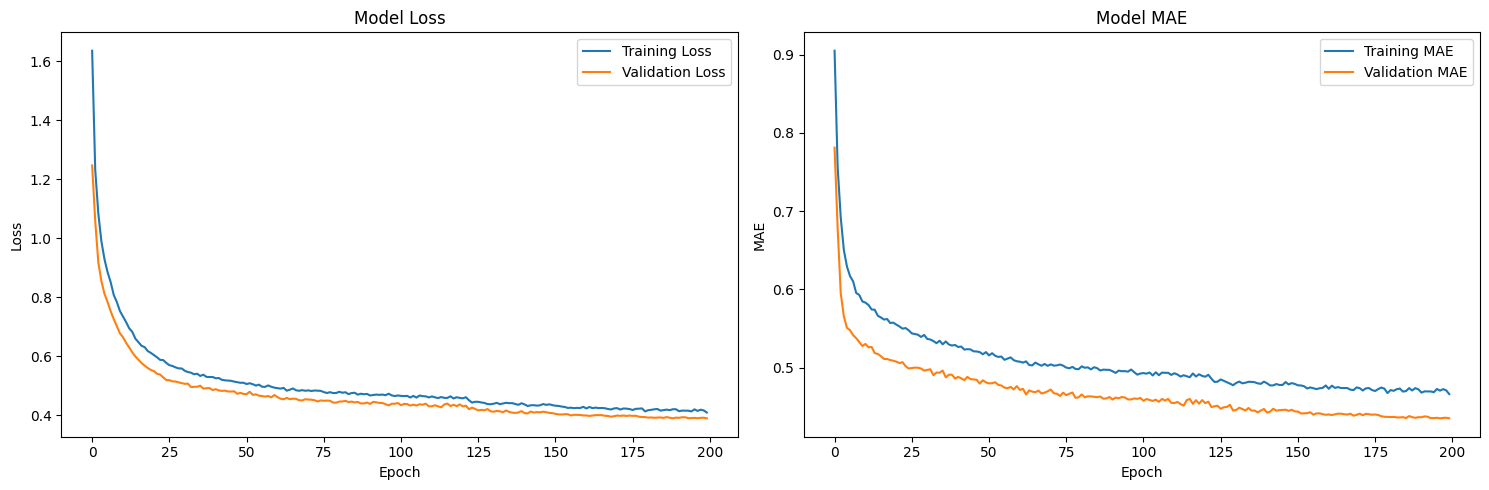

In [15]:
param_grid = {
    'sequence_length': [10],
    'forecast_horizon': [3],
    'lstm_units': [(64, 32, 16)],
    'dense_units': [(32, 16)],
    'dropout_rate': [0.2, 0.3],
    'learning_rate': [0.001],
    'batch_size': [64],
    'epochs': [200]
}

def run_grid_search(df, param_grid):
    best_config = None
    best_mae = float('inf')
    all_results = []
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in product(*values)]
    for idx, combo in enumerate(combinations):
        print(f"[{idx+1}/{len(combinations)}] Testing: {combo}")
        model = TemperatureHumidityLSTM(df, **combo)
        try:
            model.preprocess_data()
            results, _, _, _ = model.train_model()
            overall_mae = np.mean([v['avg_mae'] for v in results.values()])
            print(f"MAE: {overall_mae:.4f}")
            all_results.append((combo, overall_mae))
            if overall_mae < best_mae:
                best_mae = overall_mae
                best_config = combo
        except Exception as e:
            print(f"Error: {e}")
    print(f"Best Config: {best_config}\nBest MAE: {best_mae:.4f}")
    return best_config, all_results


def run_temperature_humidity_forecasting(df, config=None):
    """Run temperature and humidity forecasting with optional hyperparameter config"""
    print("🌡️ DEDICATED TEMPERATURE & HUMIDITY LSTM FORECASTING")
    print("=" * 70)

    # Extract or default parameters
    sequence_length = config.get('sequence_length', 10) if config else 10
    forecast_horizon = config.get('forecast_horizon', 3) if config else 3
    batch_size = config.get('batch_size', 64) if config else 64
    epochs = config.get('epochs', 200) if config else 200
    validation_split = config.get('validation_split', 0.2) if config else 0.2
    learning_rate = config.get('learning_rate', 0.001) if config else 0.001
    lstm_units = config.get('lstm_units', [128, 64, 32]) if config else [128, 64, 32]
    dense_units = config.get('dense_units', [64, 32]) if config else [64, 32]
    dropout_rate = config.get('dropout_rate', 0.2) if config else 0.2

    # Initialize model with all config parameters
    model = TemperatureHumidityLSTM(
        df=df,
        sequence_length=sequence_length,
        forecast_horizon=forecast_horizon,
        lstm_units=lstm_units,
        dense_units=dense_units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        batch_size=batch_size,
        epochs=epochs
    )

    # Preprocess and train
    model.preprocess_data()
    results, history, y_true, y_pred = model.train_model(
        validation_split=validation_split
    )

    # Plot training
    model.plot_training_history(history)

    return model, results, history, y_true, y_pred

# Assuming you ran the grid search and got best_result

# Grid search
best_result, _ = run_grid_search(df, param_grid)

# Training using best parameters
model, results, history, y_true, y_pred = run_temperature_humidity_forecasting(df, config=best_result)


In [16]:
def print_evaluation(results):
    print("\n📊 Model Evaluation Metrics by Target:")
    print("="*60)
    for target, metrics in results.items():
        print(f"\nTarget: {target}")
        print(f"  Average MAE:  {metrics['avg_mae']:.4f}")
        for day in range(len(metrics['mae'])):
            print(f"    Day {day+1}: MAE={metrics['mae'][day]:.4f}, "
                  f"RMSE={metrics['rmse'][day]:.4f}, R²={metrics['r2'][day]:.4f}, "
                  f"MAPE={metrics['mape'][day]:.2f}%")

# Call it after training
print_evaluation(results)



📊 Model Evaluation Metrics by Target:

Target: temperature_2m_max (°C)
  Average MAE:  1.9780
    Day 1: MAE=1.8230, RMSE=2.3679, R²=0.8787, MAPE=8.13%
    Day 2: MAE=2.0122, RMSE=2.6062, R²=0.8507, MAPE=9.04%
    Day 3: MAE=2.0988, RMSE=2.7369, R²=0.8352, MAPE=9.37%

Target: temperature_2m_min (°C)
  Average MAE:  1.3513
    Day 1: MAE=1.2621, RMSE=1.5793, R²=0.9229, MAPE=10.69%
    Day 2: MAE=1.3479, RMSE=1.6814, R²=0.9132, MAPE=11.43%
    Day 3: MAE=1.4438, RMSE=1.8251, R²=0.8959, MAPE=12.10%

Target: relative_humidity_2m_max (%)
  Average MAE:  6.1928
    Day 1: MAE=5.8339, RMSE=7.5125, R²=0.4023, MAPE=7.25%
    Day 2: MAE=6.2164, RMSE=7.9101, R²=0.3301, MAPE=7.67%
    Day 3: MAE=6.5282, RMSE=8.4186, R²=0.2395, MAPE=8.12%

Target: relative_humidity_2m_min (%)
  Average MAE:  7.4573
    Day 1: MAE=7.2008, RMSE=9.2140, R²=0.5163, MAPE=18.69%
    Day 2: MAE=7.4355, RMSE=9.4664, R²=0.4887, MAPE=19.23%
    Day 3: MAE=7.7357, RMSE=9.9258, R²=0.4481, MAPE=20.44%



🔮 Making 3-day temperature and humidity forecast...
--------------------------------------------------
📅 3-Day Temperature & Humidity Forecast:
  Thursday   (2025-05-01):
     🌡️ temperature_2m_max (°C): 27.98
     🌡️ temperature_2m_min (°C): 20.99
     🌡️ relative_humidity_2m_max (%): 88.21
     🌡️ relative_humidity_2m_min (%): 52.01
  Friday     (2025-05-02):
     🌡️ temperature_2m_max (°C): 27.78
     🌡️ temperature_2m_min (°C): 20.81
     🌡️ relative_humidity_2m_max (%): 89.31
     🌡️ relative_humidity_2m_min (%): 53.01
  Saturday   (2025-05-03):
     🌡️ temperature_2m_max (°C): 27.77
     🌡️ temperature_2m_min (°C): 20.70
     🌡️ relative_humidity_2m_max (%): 89.61
     🌡️ relative_humidity_2m_min (%): 52.61


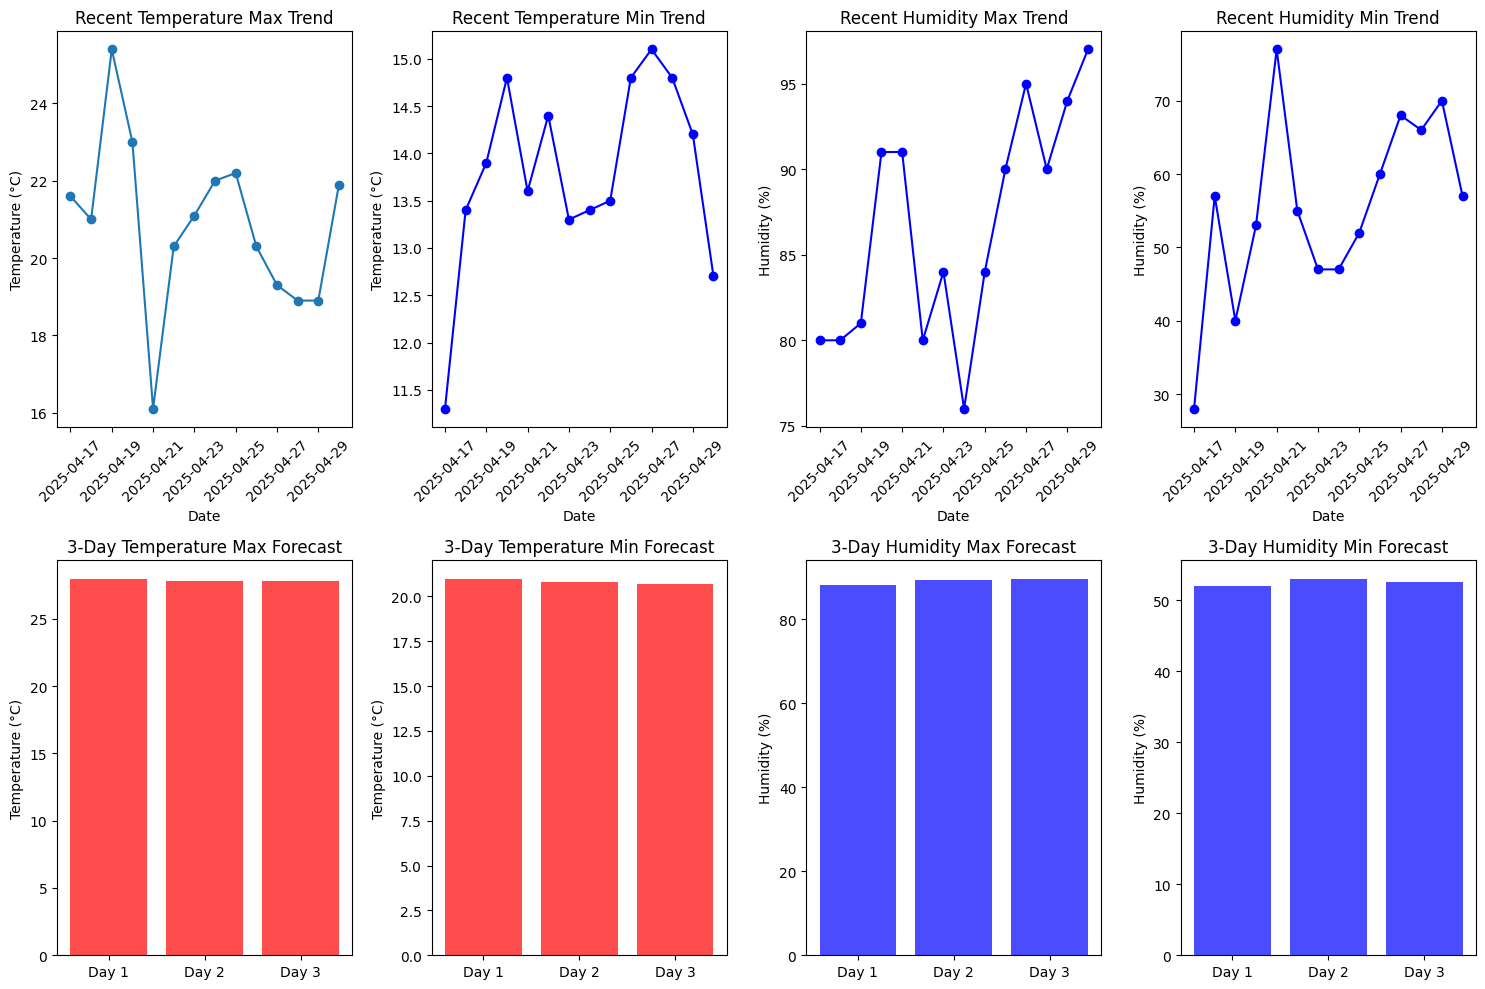

In [17]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations for temperature/humidity only"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    import pandas as pd
    import numpy as np
    
    print("\n🔮 Making 3-day temperature and humidity forecast...")
    print("-" * 50)
    
    # Get only the features used during training
    feature_cols = model.feature_cols

    # Pull only the last `sequence_length` rows
    recent_data = df[feature_cols].tail(model.sequence_length).copy()

    # Ensure numeric and same dtype
    recent_data = recent_data.apply(pd.to_numeric, errors='coerce').dropna()

    # If any rows dropped, re-pad from the top
    if len(recent_data) < model.sequence_length:
        padding_needed = model.sequence_length - len(recent_data)
        padding = np.zeros((padding_needed, len(feature_cols)))
        recent_data = np.vstack([padding, recent_data.values])
    else:
        recent_data = recent_data.values

    # Final shape must be (1, sequence_length, num_features)
    recent_data = recent_data.reshape(1, model.sequence_length, len(feature_cols)).astype(np.float32)

    try:
        # Get temperature/humidity predictions
        temp_humidity_results = model.predict_future(recent_data)
        
        # Get next 3 days
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        print("📅 3-Day Temperature & Humidity Forecast:")
        for i, (day, date) in enumerate(days_and_dates):
            print(f"  {day:10} ({date}):")
            for target_name in model.available_targets:
                value = temp_humidity_results[target_name][i]
                print(f"     🌡️ {target_name}: {value:.2f}")
        
        # Visualization
        fig, axes = plt.subplots(2, 4, figsize=(15, 10))
        
        # Plot recent temperature trends
        if 'temperature_2m_max (°C)' in df.columns:
            recent_temp = df[['date', 'temperature_2m_max (°C)']].tail(14)
            recent_temp['date'] = pd.to_datetime(recent_temp['date'])
            axes[0, 0].plot(recent_temp['date'], recent_temp['temperature_2m_max (°C)'], 'o-')
            axes[0, 0].set_title('Recent Temperature Max Trend')
            axes[0, 0].set_xlabel('Date')
            axes[0, 0].set_ylabel('Temperature (°C)')
            axes[0, 0].tick_params(axis='x', rotation=45)
        
        # Plot recent temp min trends
        if 'temperature_2m_min (°C)' in df.columns:
            recent_temp = df[['date', 'temperature_2m_min (°C)']].tail(14)
            recent_temp['date'] = pd.to_datetime(recent_temp['date'])
            axes[0, 1].plot(recent_temp['date'], recent_temp['temperature_2m_min (°C)'], 'o-', color='blue')
            axes[0, 1].set_title('Recent Temperature Min Trend')
            axes[0, 1].set_xlabel('Date')
            axes[0, 1].set_ylabel('Temperature (°C)')
            axes[0, 1].tick_params(axis='x', rotation=45)

        # Plot recent humidity ùax trends
        if 'relative_humidity_2m_max (%)' in df.columns:
            recent_humidity = df[['date', 'relative_humidity_2m_max (%)']].tail(14)
            recent_humidity['date'] = pd.to_datetime(recent_humidity['date'])
            axes[0, 2].plot(recent_humidity['date'], recent_humidity['relative_humidity_2m_max (%)'], 'o-', color='blue')
            axes[0, 2].set_title('Recent Humidity Max Trend')
            axes[0, 2].set_xlabel('Date')
            axes[0, 2].set_ylabel('Humidity (%)')
            axes[0, 2].tick_params(axis='x', rotation=45)

        # Plot recent humidity min trends
        if 'relative_humidity_2m_min (%)' in df.columns:
            recent_humidity = df[['date', 'relative_humidity_2m_min (%)']].tail(14)
            recent_humidity['date'] = pd.to_datetime(recent_humidity['date'])
            axes[0, 3].plot(recent_humidity['date'], recent_humidity['relative_humidity_2m_min (%)'], 'o-', color='blue')
            axes[0, 3].set_title('Recent Humidity Min Trend')
            axes[0, 3].set_xlabel('Date')
            axes[0, 3].set_ylabel('Humidity (%)')
            axes[0, 3].tick_params(axis='x', rotation=45)

        # Plot forecast temperature
        forecast_days = [f"Day {i+1}" for i in range(3)]
        if 'temperature_2m_max (°C)' in temp_humidity_results:
            temp_forecast = temp_humidity_results['temperature_2m_max (°C)']
            axes[1, 0].bar(forecast_days, temp_forecast, color='red', alpha=0.7)
            axes[1, 0].set_title('3-Day Temperature Max Forecast')
            axes[1, 0].set_ylabel('Temperature (°C)')

        if 'temperature_2m_min (°C)' in temp_humidity_results:
            temp_forecast = temp_humidity_results['temperature_2m_min (°C)']
            axes[1, 1].bar(forecast_days, temp_forecast, color='red', alpha=0.7)
            axes[1, 1].set_title('3-Day Temperature Min Forecast')
            axes[1, 1].set_ylabel('Temperature (°C)')
        
        # Plot forecast humidity
        if 'relative_humidity_2m_max (%)' in temp_humidity_results:
            humidity_forecast = temp_humidity_results['relative_humidity_2m_max (%)']
            axes[1, 2].bar(forecast_days, humidity_forecast, color='blue', alpha=0.7)
            axes[1, 2].set_title('3-Day Humidity Max Forecast')
            axes[1, 2].set_ylabel('Humidity (%)')

        if 'relative_humidity_2m_min (%)' in temp_humidity_results:
            humidity_forecast = temp_humidity_results['relative_humidity_2m_min (%)']
            axes[1, 3].bar(forecast_days, humidity_forecast, color='blue', alpha=0.7)
            axes[1, 3].set_title('3-Day Humidity Min Forecast')
            axes[1, 3].set_ylabel('Humidity (%)')
        
        plt.tight_layout()
        plt.show()
        
        return temp_humidity_results
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None


# Usage example:

predictions = make_predictions_and_visualize(model, df)


🌡️  TEMPERATURE & HUMIDITY PREDICTIONS

📅 Test Sequence 1:
------------------------------------------------------------

🌡️  temperature_2m_max (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      35.00 |      33.99 |       1.01 |       2.9%
    2 |      35.50 |      34.18 |       1.32 |       3.7%
    3 |      37.80 |      34.05 |       3.75 |       9.9%
------------------------------------------------------------
Sequence MAE: 2.028

🌡️  temperature_2m_min (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      21.90 |      22.35 |       0.45 |       2.0%
    2 |      23.90 |      22.59 |       1.31 |       5.5%
    3 |      24.90 |      22.78 |       2.12 |       8.5%
------------------------------------------------------------
Sequence M

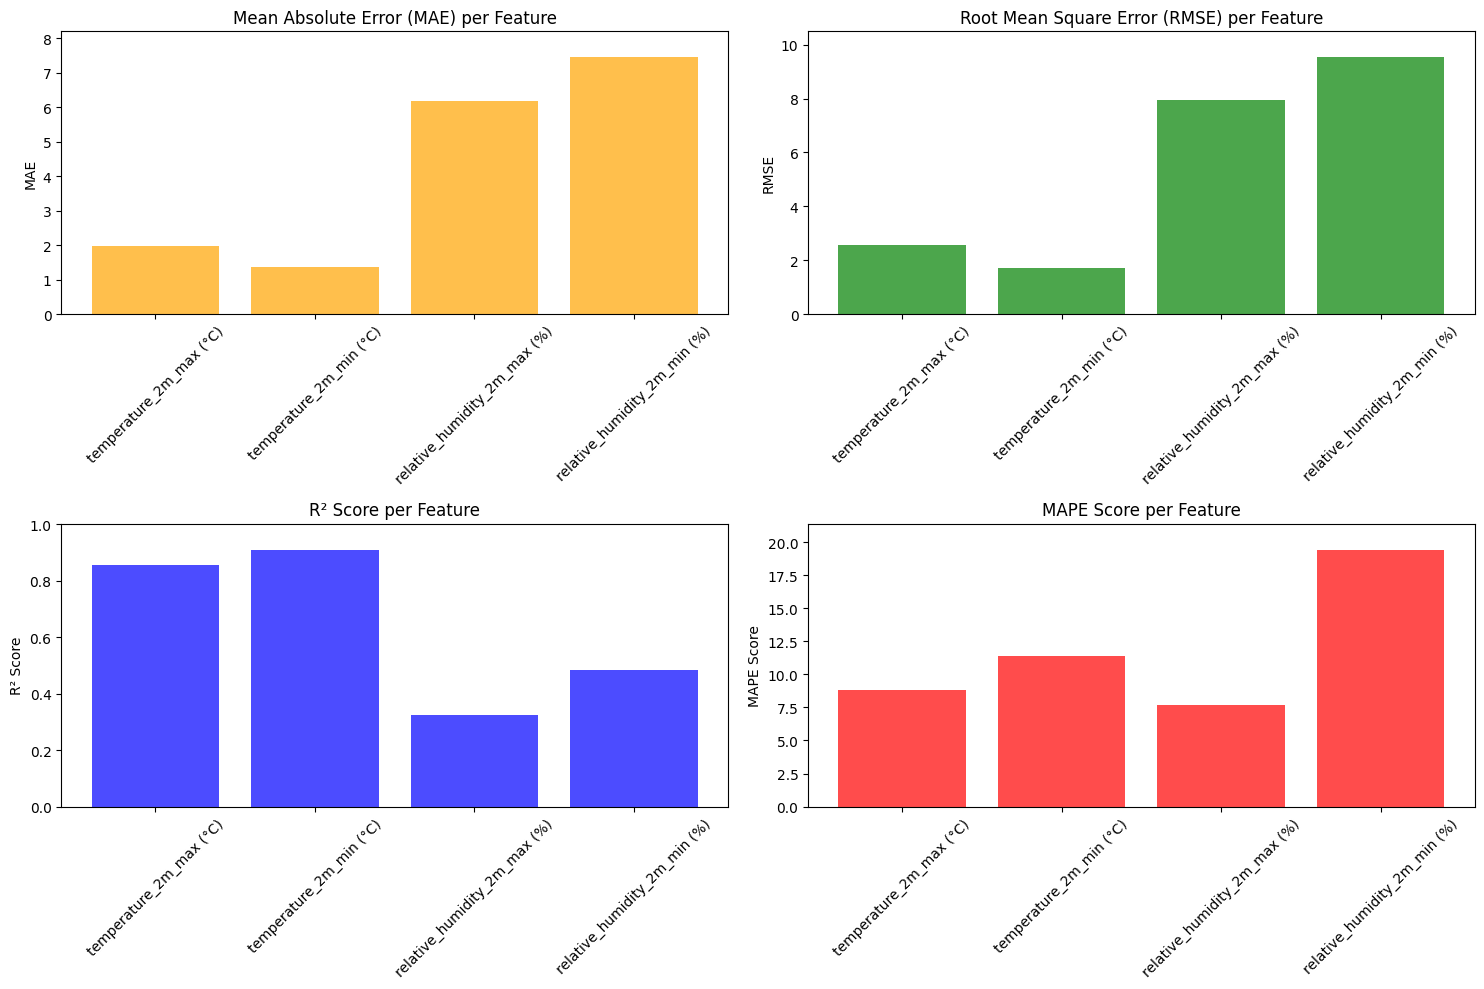


🏆 PERFORMANCE SUMMARY:
Best performing feature: temperature_2m_min (°C) (MAE: 1.351)
Worst performing feature: relative_humidity_2m_min (%) (MAE: 7.457)
Overall average MAE: 4.245
Overall average RMSE: 5.442
Overall average R²: 0.644


In [19]:
def show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=5
):
    """Display temperature and humidity regression predictions only."""
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print("🌡️  TEMPERATURE & HUMIDITY PREDICTIONS")
    print("=" * 60)

    sample_size = min(num_samples, len(y_true))

    # Get feature names from the model
    feature_names = model.available_targets if hasattr(model, 'available_targets') else [f"Feature {i}" for i in range(y_true.shape[2])]

    # Display sample predictions
    for i in range(sample_size):
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 60)

        # Create a nice table format for each feature
        for f, feature_name in enumerate(feature_names):
            print(f"\n🌡️  {feature_name}:")
            print("-" * 40)
            print(f"{'Day':>5} | {'Actual':>10} | {'Predicted':>10} | {'Error':>10} | {'% Error':>10}")
            print("-" * 60)

            mae_sequence = 0
            for day in range(model.forecast_horizon):
                actual = y_true[i, day, f]
                predicted = y_pred[i, day, f]
                error = abs(actual - predicted)
                percent_error = (error / (abs(actual) + 1e-8)) * 100
                mae_sequence += error

                print(f"{day+1:>5} | {actual:>10.2f} | {predicted:>10.2f} | {error:>10.2f} | {percent_error:>9.1f}%")

            mae_sequence /= model.forecast_horizon
            print("-" * 60)
            print(f"Sequence MAE: {mae_sequence:.3f}")

    # Overall statistics for temperature and humidity
    print(f"\n📊 OVERALL REGRESSION STATISTICS:")
    print("=" * 50)

    num_features = y_true.shape[2]

    for f, feature_name in enumerate(feature_names):
        print(f"\n🌡️  {feature_name}:")
        print("-" * 30)
        
        # Calculate metrics for this feature
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        mae = mean_absolute_error(y_true_flat, y_pred_flat)
        rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
        r2 = r2_score(y_true_flat, y_pred_flat)
        mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100
        
        print(f"  MAE:  {mae:.3f}")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  R²:   {r2:.3f}")
        print(f"  MAPE: {mape:.2f}%")
        
        # Per-day accuracy for this feature
        print(f"\n  📈 Daily Performance:")
        for day in range(model.forecast_horizon):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae = mean_absolute_error(day_true, day_pred)
            day_rmse = np.sqrt(mean_squared_error(day_true, day_pred))
            day_r2 = r2_score(day_true, day_pred)
            print(f"    Day {day+1}: MAE={day_mae:.3f}, RMSE={day_rmse:.3f}, R²={day_r2:.3f}")

    # Create visualization
    print(f"\n📈 CREATING PERFORMANCE VISUALIZATION...")
    
    # Calculate metrics for plotting
    maes = []
    rmses = []
    r2s = []
    mape = []
    for f in range(num_features):
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        maes.append(mean_absolute_error(y_true_flat, y_pred_flat))
        rmses.append(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))
        r2s.append(r2_score(y_true_flat, y_pred_flat))
        mape.append(np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100)

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # MAE plot
    axes[0, 0].bar(feature_names, maes, color='orange', alpha=0.7)
    axes[0, 0].set_title("Mean Absolute Error (MAE) per Feature")
    axes[0, 0].set_ylabel("MAE")
    axes[0, 0].set_ylim(0, max(maes) * 1.1)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # RMSE plot
    axes[0, 1].bar(feature_names, rmses, color='green', alpha=0.7)
    axes[0, 1].set_title("Root Mean Square Error (RMSE) per Feature")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].set_ylim(0, max(rmses) * 1.1)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # R² plot
    axes[1, 0].bar(feature_names, r2s, color='blue', alpha=0.7)
    axes[1, 0].set_title("R² Score per Feature")
    axes[1, 0].set_ylabel("R² Score")
    axes[1, 0].set_ylim(0, max(1.0, max(r2s) * 1.1))
    axes[1, 0].tick_params(axis='x', rotation=45)
    

    axes[1, 1].bar(feature_names, mape, color='red', alpha=0.7)
    axes[1, 1].set_title("MAPE Score per Feature")
    axes[1, 1].set_ylabel("MAPE Score")
    axes[1, 1].set_ylim(0, max(mape) * 1.1)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    
    
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n🏆 PERFORMANCE SUMMARY:")
    print("=" * 30)
    print(f"Best performing feature: {feature_names[np.argmin(maes)]} (MAE: {min(maes):.3f})")
    print(f"Worst performing feature: {feature_names[np.argmax(maes)]} (MAE: {max(maes):.3f})")
    print(f"Overall average MAE: {np.mean(maes):.3f}")
    print(f"Overall average RMSE: {np.mean(rmses):.3f}")
    print(f"Overall average R²: {np.mean(r2s):.3f}")


# Usage example - replace your original function call with this:
show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=3
)

In [20]:
def save_lstm_model(model, model_name="TemperatureHumidityLSTM", save_dir="saved_models"):
    import os
    import json
    import pickle
    from datetime import datetime
    import joblib

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)

    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)

    try:
        # 1. Save the Keras model
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print("✅ Keras model saved.")

        # 2. Save scalers
        joblib.dump(model.scaler_features, f"{model_folder}/scaler_features.pkl")
        joblib.dump(model.scaler_targets, f"{model_folder}/scaler_targets.pkl")
        print("✅ Scalers saved.")

        # 3. Save config
        config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'available_targets': model.available_targets,
            'feature_columns': model.feature_cols,
            'timestamp': timestamp,
            'model_type': 'TemperatureHumidityLSTM',
            'framework': 'TensorFlow/Keras'
        }
        with open(f"{model_folder}/model_config.json", 'w') as f:
            json.dump(config, f, indent=4)
        print("✅ Model configuration saved.")

        # 4. Save model object (without keras model to avoid issues)
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)
        with open(f"{model_folder}/full_model.pkl", 'wb') as f:
            pickle.dump(model_copy, f)
        print("✅ Full model object saved.")

        return model_folder

    except Exception as e:
        print(f"❌ Error saving model: {e}")
        return None



def load_lstm_model(model_folder):
    import os
    import json
    import pickle
    import joblib
    from tensorflow.keras.models import load_model

    try:
        print(f"📂 Loading model from: {model_folder}")

        # Load keras model
        keras_model = load_model(f"{model_folder}/keras_model.keras")

        # Load scalers
        scaler_features = joblib.load(f"{model_folder}/scaler_features.pkl")
        scaler_targets = joblib.load(f"{model_folder}/scaler_targets.pkl")

        # Load config
        with open(f"{model_folder}/model_config.json", 'r') as f:
            config = json.load(f)

        # Load full model dict
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)

        # Create empty model object
        model = TemperatureHumidityLSTM(pd.DataFrame(), config['sequence_length'], config['forecast_horizon'])
        model.model = keras_model
        model.scaler_features = scaler_features
        model.scaler_targets = scaler_targets

        # Restore other attributes
        for key, value in model_dict.items():
            setattr(model, key, value)

        print(f"✅ Model '{config['model_name']}' successfully loaded!")
        return model

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None


model_folder = save_lstm_model(model, model_name="BestTemperatureHumidityLSTM_Model1")




💾 Saving 'BestTemperatureHumidityLSTM_Model1' to: saved_models/BestTemperatureHumidityLSTM_Model1_20250706_155349
✅ Keras model saved.
✅ Scalers saved.
✅ Model configuration saved.
✅ Full model object saved.
